# Experimento B — configuración 6×7 con impacto y perfil *anytime*

**TTAP: 6 helicópteros, 7 áreas de demanda y 20–60 tareas**  

Este notebook implementa las decisiones cerradas para responder las observaciones metodológicas:

1. **Magnitud humanitaria (q_i)**: en tareas médicas, `med` es el número de personas con una condición médica que requieren evacuación; en personal, `pers` es el número de personas transportadas; en carga, `load` es la carga entregada.
2. **Prioridad compensatoria**: se conservan los pesos `medical=2.0`, `personnel=1.5`, `cargo=1.0`.
3. **Objetivo común**: MILP y heurísticas evalúan exactamente
   $
   b_i(t)=\frac{w_i q_i S_i(t)}{\sum_j w_j q_j}.
   $
4. **Dos políticas constructivas**:
   - `Greedy-Benefit`;
   - `Greedy-Density-Operational`: beneficio dividido por vuelo hacia la tarea + servicio;
5. **Perfil anytime de HiGHS**: presupuestos de 1, 5, 15, 60, 600 y 1800 segundos en modo `paper`, separando calidad primal, cota dual, *MIP gap* y certificación.
6. **Recuperación obligatoria**: ninguna tarea heurística se acepta si impide regresar a base y recuperar dentro de $T_{\max}$.
7. **Trazabilidad de ejecución**: cada escenario recibe un correlativo, un `Run ID`, fecha/hora de inicio y término, duración, estado final y uso de memoria; además se guardan *checkpoints* parciales después de cada corrida.

### Ejecución

- Mantenga `RUN_MODE = "quick"` para validar localmente la instalación y una instancia.
- Cambie a `RUN_MODE = "paper"` para ejecutar las 30 semillas, los cinco tamaños y los presupuestos completos.
- El modo `paper` comprende 150 escenarios. Su presupuesto máximo teórico de solver es 150 × (1+5+15+60+600+1800) = 372,150 s, más construcción del modelo y figuras; los *checkpoints* permiten conservar cada corrida terminada.


In [1]:
# ============================================================
# 01. IMPORTS, ENVIRONMENT AND GLOBAL CONFIGURATION
# ============================================================

import math
import os
import platform
import sys
import time
from collections import Counter, defaultdict, deque
from datetime import datetime
from zoneinfo import ZoneInfo
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.optimize import Bounds, LinearConstraint, milp
from scipy.sparse import coo_matrix

try:
    import psutil
except ImportError:
    psutil = None

if not hasattr(scipy.optimize, "milp"):
    raise RuntimeError("This notebook requires scipy.optimize.milp (SciPy >= 1.9).")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)

# -----------------------------
# Execution mode
# -----------------------------
RUN_MODE = "quick"  # "quick" or "paper"

if RUN_MODE == "quick":
    ACTIVE_TASK_COUNTS = [50]
    ACTIVE_SEEDS = [1]
    ACTIVE_HIGHS_BUDGETS = [1, 5, 15, 60, 600, 1800]
elif RUN_MODE == "paper":
    ACTIVE_TASK_COUNTS = [20, 30, 40, 50, 60]
    ACTIVE_SEEDS = list(range(1, 31))
    ACTIVE_HIGHS_BUDGETS = [1, 5, 15, 60, 600, 1800]
else:
    raise ValueError("RUN_MODE must be 'quick' or 'paper'.")

TASK_COUNTS = [20, 30, 40, 50, 60]
INSTANCE_SEEDS = list(range(1, 31))
MAX_TASKS = max(TASK_COUNTS)

TASK_GENERATOR_VERSION = "matched_v3_impact_anytime_old6x7_operational_config"
TASK_PROFILE_STREAM_ID = 21001
TASK_LOCATION_STREAM_A_ID = 22001

TASK_CLASS_NAMES = np.array(["medical", "personnel", "cargo"])
TASK_CLASS_PROBABILITIES = np.array([0.45, 0.30, 0.25])
VISUAL_REQUIRED_PROBABILITY = 0.40

EXPERIMENT_ID = "B"
N_HELICOPTERS = 6
N_DEMAND_AREAS = 7
CONFIG_TAG = "B6x7_stress"

TASK_LOCATION_STREAM_B_ID = 23001

DEFAULT_PARAMS = {
    "SERVICE_TIME": 6.0,
    "RECOVERY_TIME": 2.0,
    "TMAX": 200.0,
    "ALPHA": 0.1,
    "TIME_UNIT": 1.0,
    "USE_PRIORITY_WEIGHTS": True,
    "PRIORITY_WEIGHTS": {
        "medical": 2.0,
        "personnel": 1.5,
        "cargo": 1.0,
    },
    # Fixed class-specific references used both to make q_i dimensionless
    # and to establish the relative scale between task classes.
    "IMPACT_REFERENCES": {
        "medical": 3.0,      # medical evacuees
        "personnel": 3.0,    # transported people
        "cargo": 500.0,      # kg delivered
    },
}

EXECUTION_TIMEZONE = ZoneInfo("America/Santiago")
EXECUTION_ID = datetime.now(EXECUTION_TIMEZONE).strftime("%Y%m%d_%H%M%S%z")

RUN_PREFIX = f"{CONFIG_TAG}_{RUN_MODE}_{EXECUTION_ID}"
OUTPUT_DIR = Path("ttap_experiment_B_6x7_stress_impact_anytime_traced")

FIGURES_DIR = OUTPUT_DIR / "figures" / RUN_PREFIX
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

HIGHS_BENCHMARK_BUDGET = max(ACTIVE_HIGHS_BUDGETS)
HIGHS_METHOD = f"HiGHS-{HIGHS_BENCHMARK_BUDGET:g}s"

METHOD_ORDER = [
    "Greedy-Benefit",
    "Greedy-Density-Operational",
    HIGHS_METHOD,
]

METHOD_LABELS = {
    "Greedy-Benefit": "Greedy-Benefit",
    "Greedy-Density-Operational": "Greedy-Density",
    HIGHS_METHOD: f"HiGHS ({HIGHS_BENCHMARK_BUDGET:g} s)",
}

METHOD_COLORS = {
    "Greedy-Benefit": "#6C757D",
    "Greedy-Density-Operational": "#2A9D8F",
    HIGHS_METHOD: "#264653",
}

EXPECTED_STRUCTURE_SEED1 = {
    20: {
        "variables": 217_540,
        "states": 71_273,
        "constraints": 71_293,
    },
    30: {
        "variables": 414_022,
        "states": 115_595,
        "constraints": 115_625,
    },
    40: {
        "variables": 577_298,
        "states": 142_346,
        "constraints": 142_386,
    },
    50: {
        "variables": 747_224,
        "states": 160_411,
        "constraints": 160_461,
    },
    60: {
        "variables": 1_121_069,
        "states": 199_554,
        "constraints": 199_614,
    },
}

def save_current_figure(name, dpi=220):
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Figure saved at:", path)


memory_gb = psutil.virtual_memory().total / (1024 ** 3) if psutil is not None else np.nan
print("Computational environment")
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Processor:", platform.processor())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)
print(f"RAM: {memory_gb:.2f} GB" if np.isfinite(memory_gb) else "RAM: not reported (optional psutil package unavailable)")
print("RUN_MODE:", RUN_MODE)
print("EXECUTION_ID:", EXECUTION_ID)
print("Task counts:", ACTIVE_TASK_COUNTS)
print("Seeds:", ACTIVE_SEEDS)
print("HiGHS budgets:", ACTIVE_HIGHS_BUDGETS)

Computational environment
Python: 3.14.7
Platform: Windows-11-10.0.26200-SP0
Processor: Intel64 Family 6 Model 170 Stepping 4, GenuineIntel
NumPy: 2.5.2
Pandas: 3.0.5
SciPy: 1.18.0
Matplotlib: 3.11.1
RAM: 7.52 GB
RUN_MODE: quick
EXECUTION_ID: 20260825_155016-0400
Task counts: [50]
Seeds: [1]
HiGHS budgets: [1, 5, 15, 60, 600, 1800]


## 2. Definición matemática del valor humanitario

Para cada tarea (i), se separan tres conceptos:

| Componente | Significado | Código |
|---|---|---|
| (w_i) | prioridad compensatoria de clase | `class_weight` |
| (q_i) | magnitud humanitaria normalizada | `impact` |
| (S_i(t)) | oportunidad temporal al completar en (t) | `satisfaction(...)` |

La magnitud se calcula como

$
q_i=
\begin{cases}
\text{medical evacuees}_i/3, & i\in I^{medical},\\
\text{people transported}_i/3, & i\in I^{personnel},\\
\text{cargo delivered}_i/500, & i\in I^{cargo}.
\end{cases}
$

Las referencias son fijas y coinciden con la capacidad máxima del generador. No se usa normalización *min–max* por instancia, por lo que una misma tarea conserva su significado entre escenarios.

El valor potencial es $(v_i=w_iq_i)$, el denominador $(V^{\max}=\sum_i v_i)$, y el valor capturado es

$
J=\sum_{h}\sum_{a\in A_h^{task}}
\frac{w_{i(a)}q_{i(a)}S_{i(a)}(t_a)}{V^{\max}}x_a.
$

El denominador no cambia la solución óptima; permite comparar instancias con distinto número de tareas. $(J\in[0,1])$, y solo alcanza 1 si todas las tareas se completan con satisfacción temporal igual a 1.


In [2]:
# ============================================================
# 03. SCENARIO GENERATION AND IMPACT METADATA
# ============================================================

def default_nodes():
    return {
        "Base": (0.0, 0.0),
        "A": (8.0, 5.0),
        "B": (15.0, 12.0),
        "C": (22.0, 7.0),
        "D": (28.0, 18.0),
        "E": (35.0, 10.0),
        "F": (42.0, 22.0),
        "G": (50.0, 15.0),
    }


def default_fleet():
    return {
        "H1": {"visual": True,  "load": 650, "med": 4, "pers": 4, "speed": 150},
        "H2": {"visual": False, "load": 800, "med": 2, "pers": 6, "speed": 135},
        "H3": {"visual": True,  "load": 500, "med": 5, "pers": 3, "speed": 145},
        "H4": {"visual": False, "load": 700, "med": 3, "pers": 5, "speed": 160},
        "H5": {"visual": True, "load": 450, "med": 4, "pers": 2, "speed": 130},
        "H6": {"visual": True, "load": 600, "med": 3, "pers": 4, "speed": 155},
    }


def classify_task_priority(task):
    if task["med"] > 0:
        return "medical"
    if task["pers"] > 0:
        return "personnel"
    if task["load"] > 0:
        return "cargo"
    raise ValueError("Task has no positive operational requirement.")


def raw_humanitarian_impact(task, task_class):
    """Physical output used to define q_i; not a resource-cost score."""
    if task_class == "medical":
        return float(task["med"]), "medical evacuees"
    if task_class == "personnel":
        return float(task["pers"]), "people transported"
    if task_class == "cargo":
        return float(task["load"]), "kg delivered"
    raise ValueError(f"Unknown task class: {task_class}")


def assign_task_value_metadata(scenario):
    params = scenario["params"]
    weights = params["PRIORITY_WEIGHTS"]
    references = params["IMPACT_REFERENCES"]
    use_weights = params["USE_PRIORITY_WEIGHTS"]

    for task in scenario["tasks"].values():
        task_class = classify_task_priority(task)
        raw_impact, impact_unit = raw_humanitarian_impact(task, task_class)
        reference = float(references[task_class])
        if reference <= 0:
            raise ValueError("Every impact reference must be positive.")

        task["priority_class"] = task_class
        task["class_weight"] = float(weights[task_class]) if use_weights else 1.0
        task["raw_impact"] = raw_impact
        task["impact_unit"] = impact_unit
        task["impact_reference"] = reference
        task["impact"] = raw_impact / reference
        task["potential_value"] = task["class_weight"] * task["impact"]

    total_potential_value = sum(
        task["potential_value"] for task in scenario["tasks"].values()
    )
    if total_potential_value <= 0:
        raise ValueError("Total potential mission value must be positive.")

    scenario["total_potential_value"] = float(total_potential_value)
    return scenario


def make_reproducible_rng(seed, stream_id):
    return np.random.default_rng(
        np.random.SeedSequence([int(seed), int(stream_id)])
    )


REFERENCE_FLEET = {
    h: {k: v for k, v in data.items() if k != "speed"}
    for h, data in default_fleet().items()
}


def task_is_structurally_feasible(task, fleet=REFERENCE_FLEET):
    return any(
        (not task["visual"] or helo["visual"])
        and helo["load"] >= task["load"]
        and helo["med"] >= task["med"]
        and helo["pers"] >= task["pers"]
        for helo in fleet.values()
    )


def draw_task_profile(rng):
    task_class = str(rng.choice(TASK_CLASS_NAMES, p=TASK_CLASS_PROBABILITIES))
    visual = bool(rng.random() < VISUAL_REQUIRED_PROBABILITY)

    if task_class == "medical":
        load = int(rng.choice(np.arange(50, 501, 50)))
        med = int(rng.integers(1, 4))
        pers = int(rng.integers(0, 4))
    elif task_class == "personnel":
        load = int(rng.choice(np.arange(50, 501, 50)))
        med = 0
        pers = int(rng.integers(1, 4))
    else:
        load = int(rng.choice(np.arange(100, 501, 50)))
        med = 0
        pers = 0

    t_opt = int(rng.integers(8, 36))
    t_eff = t_opt + int(rng.integers(12, 27))
    t_ineff = t_eff + int(rng.integers(20, 61))

    task = {
        "visual": visual,
        "load": load,
        "med": med,
        "pers": pers,
        "t_opt": float(t_opt),
        "t_eff": float(t_eff),
        "t_ineff": float(t_ineff),
    }
    if classify_task_priority(task) != task_class:
        raise AssertionError("Generated class is inconsistent.")
    if not task_is_structurally_feasible(task):
        raise AssertionError("Generated task is structurally infeasible.")
    return task


def task_prefix_is_complex(tasks, n_tasks):
    prefix = [tasks[i] for i in range(1, n_tasks + 1)]
    class_counts = Counter(classify_task_priority(task) for task in prefix)
    minimum_class_count = max(3, int(math.floor(0.12 * n_tasks)))
    if any(class_counts[name] < minimum_class_count for name in TASK_CLASS_NAMES):
        return False

    visual_count = sum(task["visual"] for task in prefix)
    if not (math.ceil(0.25 * n_tasks) <= visual_count <= math.floor(0.60 * n_tasks)):
        return False

    resource_vectors = {
        (task["load"], task["med"], task["pers"]) for task in prefix
    }
    return len(resource_vectors) >= math.ceil(0.65 * n_tasks)


def generate_task_profiles(n_tasks=20, seed=1):
    if n_tasks not in TASK_COUNTS:
        raise ValueError(f"n_tasks must belong to {TASK_COUNTS}.")
    rng = make_reproducible_rng(seed, TASK_PROFILE_STREAM_ID)
    for _ in range(10000):
        candidate = {
            task_id: draw_task_profile(rng)
            for task_id in range(1, MAX_TASKS + 1)
        }
        if all(task_prefix_is_complex(candidate, n) for n in TASK_COUNTS):
            return {
                task_id: candidate[task_id].copy()
                for task_id in range(1, n_tasks + 1)
            }
    raise RuntimeError("Could not generate a sufficiently heterogeneous task set.")


def generate_asymmetric_locations(
    n_tasks,
    seed,
    node_choices,
):
    node_choices = list(node_choices)

    if len(node_choices) != N_DEMAND_AREAS:
        raise ValueError(
            f"Experiment {EXPERIMENT_ID} requires exactly "
            f"{N_DEMAND_AREAS} demand areas."
        )

    base_probabilities = np.array([
        0.30,
        0.22,
        0.16,
        0.12,
        0.09,
        0.07,
        0.04,
    ])

    rng = make_reproducible_rng(
        seed,
        TASK_LOCATION_STREAM_B_ID,
    )

    for _ in range(10000):
        hotspot_order = list(
            rng.permutation(node_choices)
        )

        sequence = list(
            rng.choice(
                hotspot_order,
                size=MAX_TASKS,
                replace=True,
                p=base_probabilities,
            )
        )

        valid = True

        for prefix_size in TASK_COUNTS:
            counts = Counter(
                sequence[:prefix_size]
            )

            values = np.array([
                counts[node]
                for node in node_choices
            ])

            required_imbalance = max(
                3,
                int(math.ceil(
                    0.10 * prefix_size
                )),
            )

            if (
                not np.all(values >= 1)
                or values.max() - values.min()
                < required_imbalance
            ):
                valid = False
                break

        if valid:
            return {
                task_id:
                    str(sequence[task_id - 1])
                for task_id
                in range(1, n_tasks + 1)
            }

    raise RuntimeError(
        "Could not generate an asymmetric "
        "spatial allocation."
    )


def create_scenario(n_tasks=20, seed=1, scenario_id=None, params=None):
    if scenario_id is None:
        scenario_id = (
        f"{CONFIG_TAG}_T{n_tasks}_S{seed}"
    )
    merged_params = DEFAULT_PARAMS.copy()
    merged_params["PRIORITY_WEIGHTS"] = DEFAULT_PARAMS["PRIORITY_WEIGHTS"].copy()
    merged_params["IMPACT_REFERENCES"] = DEFAULT_PARAMS["IMPACT_REFERENCES"].copy()
    if params:
        merged_params.update(params)

    nodes = default_nodes()
    tasks = generate_task_profiles(n_tasks=n_tasks, seed=seed)
    task_to_node = generate_asymmetric_locations(
        n_tasks=n_tasks,
        seed=seed,
        node_choices=[node for node in nodes if node != "Base"],
    )
    scenario = {
        "scenario_id": scenario_id,
        "experiment": EXPERIMENT_ID,
        "task_generator_version": TASK_GENERATOR_VERSION,
        "seed": seed,
        "nodes": nodes,
        "helicopters": default_fleet(),
        "tasks": tasks,
        "task_to_node": task_to_node,
        "params": merged_params,
    }
    return assign_task_value_metadata(scenario)


def validate_scenario_structure(scenario):
    if len(scenario["helicopters"]) != N_HELICOPTERS:
        raise AssertionError(f"Experiment {EXPERIMENT_ID} must contain "
        f"{N_HELICOPTERS} helicopters.")
    demand_areas = [
        node
        for node in scenario["nodes"]
        if node != "Base"
    ]
    if len(demand_areas) != N_DEMAND_AREAS:
        raise AssertionError(
            f"Experiment {EXPERIMENT_ID} must contain "
            f"{N_DEMAND_AREAS} demand areas."
        )
    for task_id, task in scenario["tasks"].items():
        if not task_is_structurally_feasible(task, scenario["helicopters"]):
            raise AssertionError(f"Task {task_id} is structurally infeasible.")
        if not (0 < task["impact"] <= 1):
            raise AssertionError(f"Task {task_id} has invalid normalized impact.")
        if not math.isclose(
            task["potential_value"],
            task["class_weight"] * task["impact"],
            rel_tol=0,
            abs_tol=1e-12,
        ):
            raise AssertionError(f"Task {task_id} has inconsistent value metadata.")
    return True


scenario_check = create_scenario(20, 1)
validate_scenario_structure(scenario_check)
print("Scenario generator and impact metadata validation passed.")

Scenario generator and impact metadata validation passed.


In [3]:
# ============================================================
# 04. COMMON FUNCTIONS AND TEMPORAL SATISFACTION
# ============================================================

def helo_to_int(h):
    if isinstance(h, str):
        h = h.strip()
        return int(h[1:]) if h.startswith("H") else int(h)
    return int(h)


def euclidean_distance(scenario, node_a, node_b):
    xa, ya = scenario["nodes"][node_a]
    xb, yb = scenario["nodes"][node_b]
    return math.hypot(xa - xb, ya - yb)


def travel_time_minutes(scenario, h, node_a, node_b):
    if node_a == node_b:
        return 0.0
    distance = euclidean_distance(scenario, node_a, node_b)
    return 60.0 * distance / scenario["helicopters"][h]["speed"]


def logistic_component(alpha, t, t_eff):
    return 1.0 / (1.0 + math.exp(alpha * (t - t_eff)))


def satisfaction(scenario, t, task):
    """Anchored function: S(t_opt)=1, S(t_eff)=0.5, S(t_ineff)=0."""
    alpha = float(scenario["params"]["ALPHA"])
    t_opt = float(task["t_opt"])
    t_eff = float(task["t_eff"])
    t_ineff = float(task["t_ineff"])
    if not (0 <= t_opt < t_eff < t_ineff):
        raise ValueError("Temporal thresholds must satisfy 0 <= t_opt < t_eff < t_ineff.")
    if alpha <= 0:
        raise ValueError("ALPHA must be positive.")
    if t <= t_opt:
        return 1.0
    if t >= t_ineff:
        return 0.0

    value_t = logistic_component(alpha, t, t_eff)
    if t <= t_eff:
        value_opt = logistic_component(alpha, t_opt, t_eff)
        value = 0.5 + 0.5 * (value_t - 0.5) / (value_opt - 0.5)
    else:
        value_ineff = logistic_component(alpha, t_ineff, t_eff)
        value = 0.5 * (value_t - value_ineff) / (0.5 - value_ineff)
    return float(np.clip(value, 0.0, 1.0))


def task_benefit(scenario, task_id, finish_time):
    task = scenario["tasks"][task_id]
    return (
        task["potential_value"]
        * satisfaction(scenario, finish_time, task)
        / scenario["total_potential_value"]
    )


def can_execute_task_by_resources(scenario, h, task_id, load, med, pers):
    helo = scenario["helicopters"][h]
    task = scenario["tasks"][task_id]
    return (
        (not task["visual"] or helo["visual"])
        and load >= task["load"]
        and med >= task["med"]
        and pers >= task["pers"]
    )


def ceil_steps(minutes, time_unit):
    return int(math.ceil((minutes - 1e-9) / time_unit))


def time_from_step(k, time_unit):
    return k * time_unit


def discretized_finish(start_time, duration, time_unit):
    k_now = int(round(start_time / time_unit))
    return time_from_step(k_now + ceil_steps(duration, time_unit), time_unit)


def make_state(node, k, load, med, pers):
    return (node, int(k), int(load), int(med), int(pers))


def start_state(scenario, h):
    helo = scenario["helicopters"][h]
    return make_state("Base", 0, helo["load"], helo["med"], helo["pers"])


def sink_state():
    return ("SINK", -1, 0, 0, 0)


def validate_temporal_satisfaction(scenario):
    for task in scenario["tasks"].values():
        assert math.isclose(satisfaction(scenario, task["t_opt"], task), 1.0, abs_tol=1e-12)
        assert math.isclose(satisfaction(scenario, task["t_eff"], task), 0.5, abs_tol=1e-12)
        assert math.isclose(satisfaction(scenario, task["t_ineff"], task), 0.0, abs_tol=1e-12)
    return True


validate_temporal_satisfaction(scenario_check)
print("Temporal satisfaction validation passed.")


Temporal satisfaction validation passed.


## 5. Heurísticas constructivas

Para el helicóptero disponible más temprano se evalúan solamente las tareas factibles cuyo cumplimiento permita regresar a la base y completar la recuperación dentro del horizonte.
El Greedy tradicional selecciona la tarea con mayor beneficio:

$
\text{score}^{B}_{hi}=b_i(C_{hi}).
$

La heurística de densidad selecciona la tarea con mayor beneficio por unidad de tiempo operacional necesario para completarla:

$
\text{score}^{DO}_{hi} = \frac{b_i(C_{hi})} {\tau_{h,n_h,n_i}+s_i}.
$

El retorno a la base y la recuperación no forman parte del denominador, pero permanecen como condiciones obligatorias de factibilidad.

In [4]:
# ============================================================
# 06. GREEDY POLICIES WITH MANDATORY RECOVERY
# ============================================================

GREEDY_RULES = {
    "benefit": "Greedy-Benefit",
    "density_operational": "Greedy-Density-Operational",
}


def greedy_score(rule, benefit, operational_duration):
    if rule == "benefit":
        return benefit

    if rule == "density_operational":
        return benefit / operational_duration

    raise ValueError(f"Unknown greedy rule: {rule}")


def solve_greedy_ttap(scenario, rule="benefit", verbose=False):
    if rule not in GREEDY_RULES:
        raise ValueError(f"rule must be one of {sorted(GREEDY_RULES)}")
    method_name = GREEDY_RULES[rule]
    t0 = time.perf_counter()

    params = scenario["params"]
    tasks = scenario["tasks"]
    task_to_node = scenario["task_to_node"]
    helicopters = scenario["helicopters"]
    service_time = params["SERVICE_TIME"]
    recovery_time = params["RECOVERY_TIME"]
    tmax = params["TMAX"]
    time_unit = params["TIME_UNIT"]

    helo_state = {
        h: {
            "node": "Base",
            "available_time": 0.0,
            "load": helo["load"],
            "med": helo["med"],
            "pers": helo["pers"],
            "blocked": False,
        }
        for h, helo in helicopters.items()
    }
    pending = set(tasks)
    rows = []

    while pending:
        active_helos = [h for h in helicopters if not helo_state[h]["blocked"]]
        if not active_helos:
            break
        h = min(
            active_helos,
            key=lambda name: (helo_state[name]["available_time"], name),
        )
        state = helo_state[h]
        if state["available_time"] >= tmax:
            state["blocked"] = True
            continue

        current_node = state["node"]
        current_time = state["available_time"]
        candidates = []

        for task_id in sorted(pending):
            if not can_execute_task_by_resources(
                scenario,
                h,
                task_id,
                state["load"],
                state["med"],
                state["pers"],
            ):
                continue

            task_node = task_to_node[task_id]
            outbound_flight = travel_time_minutes(scenario, h, current_node, task_node)
            operational_duration = outbound_flight + service_time
            finish_time = discretized_finish(current_time, operational_duration, time_unit)
            if finish_time > tmax:
                continue

            return_flight = travel_time_minutes(scenario, h, task_node, "Base")
            return_duration = return_flight + recovery_time
            mission_finish_time = discretized_finish(finish_time, return_duration, time_unit)
            if mission_finish_time > tmax:
                continue

            benefit = task_benefit(scenario, task_id, finish_time)
            if benefit <= 0:
                continue

            cycle_duration = operational_duration + return_duration
            score = greedy_score(rule, benefit, operational_duration)
            candidates.append({
                "task_id": task_id,
                "task_node": task_node,
                "outbound_flight": outbound_flight,
                "return_flight": return_flight,
                "operational_duration": operational_duration,
                "cycle_duration": cycle_duration,
                "finish_time": finish_time,
                "mission_finish_time": mission_finish_time,
                "benefit": benefit,
                "score": score,
            })

        if candidates:
            best = min(
                candidates,
                key=lambda item: (
                    -item["score"],
                    -item["benefit"],
                    item["finish_time"],
                    item["task_id"],
                ),
            )
            task_id = best["task_id"]
            task = tasks[task_id]
            start_node = current_node
            start_time = current_time

            state["node"] = best["task_node"]
            state["available_time"] = best["finish_time"]
            state["load"] -= task["load"]
            state["med"] -= task["med"]
            state["pers"] -= task["pers"]
            pending.remove(task_id)

            rows.append({
                "Scenario": scenario["scenario_id"],
                "Method": method_name,
                "Helo ID": helo_to_int(h),
                "Task ID": task_id,
                "Task Class": task["priority_class"],
                "Start Node": start_node,
                "Node": best["task_node"],
                "Start Time": start_time,
                "Flight Time": best["outbound_flight"],
                "Service Time": service_time,
                "Total Task Time": best["operational_duration"],
                "Cycle Time Proxy": best["cycle_duration"],
                "Completion Time": best["finish_time"],
                "Benefit": best["benefit"],
                "Selection Score": best["score"],
                "Raw Impact": task["raw_impact"],
                "Normalized Impact": task["impact"],
                "Remaining Load": state["load"],
                "Remaining Medical": state["med"],
                "Remaining Personnel": state["pers"],
                "Status": "Task Executed",
            })
            if verbose:
                print(f"{method_name}: {h} -> T{task_id} at {best['finish_time']:.1f}")
            continue

        # No feasible positive-value task: recover if away from Base.
        if current_node != "Base":
            flight = travel_time_minutes(scenario, h, current_node, "Base")
            duration = flight + recovery_time
            finish_time = discretized_finish(current_time, duration, time_unit)
            if finish_time > tmax:
                state["blocked"] = True
                continue
            helo = helicopters[h]
            state.update({
                "node": "Base",
                "available_time": finish_time,
                "load": helo["load"],
                "med": helo["med"],
                "pers": helo["pers"],
            })
            rows.append({
                "Scenario": scenario["scenario_id"],
                "Method": method_name,
                "Helo ID": helo_to_int(h),
                "Task ID": "Idle",
                "Task Class": "return",
                "Start Node": current_node,
                "Node": "Base",
                "Start Time": current_time,
                "Flight Time": flight,
                "Service Time": recovery_time,
                "Total Task Time": duration,
                "Cycle Time Proxy": duration,
                "Completion Time": finish_time,
                "Benefit": 0.0,
                "Selection Score": 0.0,
                "Raw Impact": 0.0,
                "Normalized Impact": 0.0,
                "Remaining Load": state["load"],
                "Remaining Medical": state["med"],
                "Remaining Personnel": state["pers"],
                "Status": "Return/Recovery",
            })
        else:
            state["blocked"] = True

    # Final mandatory recovery for every used helicopter still away from Base.
    for h, state in helo_state.items():
        if state["node"] == "Base":
            continue
        current_node = state["node"]
        current_time = state["available_time"]
        flight = travel_time_minutes(scenario, h, current_node, "Base")
        duration = flight + recovery_time
        finish_time = discretized_finish(current_time, duration, time_unit)
        if finish_time > tmax:
            raise RuntimeError(f"{method_name}: {h} cannot complete mandatory recovery.")
        helo = helicopters[h]
        state.update({
            "node": "Base",
            "available_time": finish_time,
            "load": helo["load"],
            "med": helo["med"],
            "pers": helo["pers"],
        })
        rows.append({
            "Scenario": scenario["scenario_id"],
            "Method": method_name,
            "Helo ID": helo_to_int(h),
            "Task ID": "Idle",
            "Task Class": "return",
            "Start Node": current_node,
            "Node": "Base",
            "Start Time": current_time,
            "Flight Time": flight,
            "Service Time": recovery_time,
            "Total Task Time": duration,
            "Cycle Time Proxy": duration,
            "Completion Time": finish_time,
            "Benefit": 0.0,
            "Selection Score": 0.0,
            "Raw Impact": 0.0,
            "Normalized Impact": 0.0,
            "Remaining Load": state["load"],
            "Remaining Medical": state["med"],
            "Remaining Personnel": state["pers"],
            "Status": "Return/Recovery",
        })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["Completion Time", "Helo ID"]).reset_index(drop=True)
    summary = {
        "Scenario": scenario["scenario_id"],
        "Method": method_name,
        "Runtime sec": time.perf_counter() - t0,
        "Solver Time sec": np.nan,
        "Graph Time sec": np.nan,
        "Matrix Time sec": np.nan,
        "End-to-end sec": time.perf_counter() - t0,
        "Optimal Certified": False,
        "MIP Gap": np.nan,
        "Primal Bound": np.nan,
        "Dual Bound": np.nan,
        "Variables": np.nan,
        "Constraints": np.nan,
        "Nonzeros": np.nan,
        "Solver Message": "Constructive heuristic",
        "Has Incumbent": True,
    }
    return df, summary


## 7. MILP estado–arco y comparación *anytime*

La red y las matrices se construyen **una vez por instancia**. Después se reinicia HiGHS con cada presupuesto temporal sobre el mismo problema. Esto permite separar:

- tiempo de construcción del grafo;
- tiempo de construcción de matrices;
- tiempo del solver;
- tiempo *end-to-end*.

Las ejecuciones limitadas se denominan `HiGHS-1s`, `HiGHS-5s`, etc.; solo se usa `Optimal Certified=True` cuando HiGHS termina con prueba de optimalidad. Una solución factible no certificada sigue siendo un *incumbent* válido y se reporta junto con su cota y *gap*.

Esta versión usa `scipy.optimize.milp`; por ello cada presupuesto corresponde a una resolución independiente, sin *warm start*.


In [5]:
# ============================================================
# 08. EXACT TTAP MILP — REUSABLE STATE-ARC MODEL
# ============================================================

def build_state_graph_for_helicopter(scenario, h):
    params = scenario["params"]
    tasks = scenario["tasks"]
    task_to_node = scenario["task_to_node"]
    helicopters = scenario["helicopters"]
    service_time = params["SERVICE_TIME"]
    recovery_time = params["RECOVERY_TIME"]
    tmax = params["TMAX"]
    time_unit = params["TIME_UNIT"]
    tmax_steps = int(round(tmax / time_unit))

    source = start_state(scenario, h)
    sink = sink_state()
    states = {source}
    queue = deque([source])
    arcs = []

    while queue:
        current_state = queue.popleft()
        node, k, load, med, pers = current_state
        current_time = time_from_step(k, time_unit)

        for task_id in sorted(tasks):
            if not can_execute_task_by_resources(scenario, h, task_id, load, med, pers):
                continue
            task_node = task_to_node[task_id]
            flight = travel_time_minutes(scenario, h, node, task_node)
            duration_steps = ceil_steps(flight + service_time, time_unit)
            k_new = k + duration_steps
            if k_new > tmax_steps:
                continue
            finish_time = time_from_step(k_new, time_unit)
            task = tasks[task_id]
            new_state = make_state(
                task_node,
                k_new,
                load - task["load"],
                med - task["med"],
                pers - task["pers"],
            )
            benefit = task_benefit(scenario, task_id, finish_time)
            if benefit <= 0:
                continue
            arcs.append({
                "h": h,
                "from": current_state,
                "to": new_state,
                "kind": "task",
                "task": task_id,
                "start_time": current_time,
                "finish_time": finish_time,
                "flight_time": flight,
                "service_time": service_time,
                "benefit": benefit,
            })
            if new_state not in states:
                states.add(new_state)
                queue.append(new_state)

        if node != "Base":
            flight = travel_time_minutes(scenario, h, node, "Base")
            duration_steps = ceil_steps(flight + recovery_time, time_unit)
            k_new = k + duration_steps
            if k_new <= tmax_steps:
                helo = helicopters[h]
                new_state = make_state(
                    "Base", k_new, helo["load"], helo["med"], helo["pers"]
                )
                arcs.append({
                    "h": h,
                    "from": current_state,
                    "to": new_state,
                    "kind": "return",
                    "task": None,
                    "start_time": current_time,
                    "finish_time": time_from_step(k_new, time_unit),
                    "flight_time": flight,
                    "service_time": recovery_time,
                    "benefit": 0.0,
                })
                if new_state not in states:
                    states.add(new_state)
                    queue.append(new_state)

    states.add(sink)
    full = helicopters[h]
    for state in list(states):
        if state == sink:
            continue
        node, k, load, med, pers = state
        recovered = (
            node == "Base"
            and load == full["load"]
            and med == full["med"]
            and pers == full["pers"]
        )
        if recovered:
            arcs.append({
                "h": h,
                "from": state,
                "to": sink,
                "kind": "end",
                "task": None,
                "start_time": time_from_step(k, time_unit),
                "finish_time": time_from_step(k, time_unit),
                "flight_time": 0.0,
                "service_time": 0.0,
                "benefit": 0.0,
            })
    return list(states), arcs


def build_full_exact_graph(scenario, verbose=False):
    states_by_h = {}
    arcs_by_h = {}
    all_arcs = []
    for h in scenario["helicopters"]:
        states, arcs = build_state_graph_for_helicopter(scenario, h)
        states_by_h[h] = states
        arcs_by_h[h] = arcs
        all_arcs.extend(arcs)
        if verbose:
            print(f"{h}: {len(states):,} states | {len(arcs):,} arcs")
    return states_by_h, arcs_by_h, all_arcs

def build_exact_milp_matrices(scenario, states_by_h, arcs_by_h, all_arcs):
    helicopters = scenario["helicopters"]
    tasks = scenario["tasks"]
    n_vars = len(all_arcs)
    c = np.array([-arc["benefit"] for arc in all_arcs], dtype=float)
    integrality = np.ones(n_vars, dtype=int)
    bounds = Bounds(np.zeros(n_vars), np.ones(n_vars))

    row_idx, col_idx, values = [], [], []
    rhs_lb, rhs_ub = [], []
    current_row = 0

    offsets = {}
    offset = 0
    for h in helicopters:
        offsets[h] = offset
        offset += len(arcs_by_h[h])

    for h in helicopters:
        outgoing = defaultdict(list)
        incoming = defaultdict(list)
        for local_index, arc in enumerate(arcs_by_h[h]):
            j = offsets[h] + local_index
            outgoing[arc["from"]].append(j)
            incoming[arc["to"]].append(j)

        source = start_state(scenario, h)
        sink = sink_state()
        for state in states_by_h[h]:
            for j in outgoing.get(state, []):
                row_idx.append(current_row); col_idx.append(j); values.append(1.0)
            for j in incoming.get(state, []):
                row_idx.append(current_row); col_idx.append(j); values.append(-1.0)
            rhs = 1.0 if state == source else -1.0 if state == sink else 0.0
            rhs_lb.append(rhs); rhs_ub.append(rhs)
            current_row += 1

    task_to_arc_indices = defaultdict(list)
    for j, arc in enumerate(all_arcs):
        if arc["kind"] == "task":
            task_to_arc_indices[arc["task"]].append(j)
    for task_id in tasks:
        for j in task_to_arc_indices[task_id]:
            row_idx.append(current_row); col_idx.append(j); values.append(1.0)
        rhs_lb.append(-np.inf); rhs_ub.append(1.0)
        current_row += 1

    A = coo_matrix(
        (values, (row_idx, col_idx)), shape=(current_row, n_vars)
    ).tocsr()
    constraints = LinearConstraint(
        A,
        np.asarray(rhs_lb, dtype=float),
        np.asarray(rhs_ub, dtype=float),
    )
    return c, integrality, bounds, constraints, A


def prepare_exact_problem(scenario, verbose=False):
    graph_start = time.perf_counter()
    states_by_h, arcs_by_h, all_arcs = build_full_exact_graph(scenario, verbose)
    graph_time = time.perf_counter() - graph_start

    matrix_start = time.perf_counter()
    c, integrality, bounds, constraints, A = build_exact_milp_matrices(
        scenario, states_by_h, arcs_by_h, all_arcs
    )
    matrix_time = time.perf_counter() - matrix_start
    return {
        "states_by_h": states_by_h,
        "arcs_by_h": arcs_by_h,
        "all_arcs": all_arcs,
        "c": c,
        "integrality": integrality,
        "bounds": bounds,
        "constraints": constraints,
        "A": A,
        "graph_time": graph_time,
        "matrix_time": matrix_time,
    }


def solve_prepared_highs(scenario, package, time_limit, mip_rel_gap=1e-6, verbose=False):
    method_name = f"HiGHS-{time_limit:g}s"
    solver_start = time.perf_counter()
    result = milp(
        c=package["c"],
        integrality=package["integrality"],
        bounds=package["bounds"],
        constraints=package["constraints"],
        options={
            "time_limit": float(time_limit),
            "mip_rel_gap": float(mip_rel_gap),
            "disp": verbose,
        },
    )
    solver_time = time.perf_counter() - solver_start
    graph_time = package["graph_time"]
    matrix_time = package["matrix_time"]
    def finite_float(value):
        try:
            converted = float(value)
        except (TypeError, ValueError):
            return np.nan
        return converted if np.isfinite(converted) else np.nan

    objective = finite_float(getattr(result, "fun", np.nan))
    has_incumbent = result.x is not None and np.isfinite(objective)
    has_solver_incumbent = (result.x is not None and np.isfinite(objective)
                            )
    primal = (-objective 
              if has_solver_incumbent
                else np.nan
    )

    has_positive_plan = (
        has_solver_incumbent
        and primal > 0.0
    )
    primal = -objective if has_incumbent else np.nan
    raw_dual = finite_float(getattr(result, "mip_dual_bound", np.nan))
    dual = -raw_dual if np.isfinite(raw_dual) else np.nan
    gap = finite_float(getattr(result, "mip_gap", np.nan))
    certified = bool(result.success and getattr(result, "status", None) == 0)

    summary = {
        "Scenario": scenario["scenario_id"],
        "Method": method_name,
        "Runtime sec": solver_time,
        "Solver Time sec": solver_time,
        "Graph Time sec": graph_time,
        "Matrix Time sec": matrix_time,
        "End-to-end sec": graph_time + matrix_time + solver_time,
        "Optimal Certified": certified,
        "MIP Gap": 0.0 if certified else gap,
        "Primal Bound": primal,
        "Dual Bound": primal if certified else dual,
        "MIP Nodes": getattr(result, "mip_node_count", np.nan),
        "Variables": len(package["all_arcs"]),
        "Constraints": package["A"].shape[0],
        "Nonzeros": package["A"].nnz,
        "Solver Message": result.message,
        "Time Limit sec": float(time_limit),
        "Has Incumbent": has_incumbent,
        "Has Positive Plan": has_positive_plan,
        "Has Incumbent": has_solver_incumbent,
        "Solver Status Code": getattr(result, "status", np.nan),
    }
    return result, summary


def decode_exact_solution(scenario, result, all_arcs, method_name):
    if result.x is None:
        return pd.DataFrame()
    selected_arcs = [all_arcs[j] for j, value in enumerate(result.x) if value > 0.5]
    selected_by_h = defaultdict(list)
    for arc in selected_arcs:
        selected_by_h[arc["h"]].append(arc)

    rows = []
    for h in scenario["helicopters"]:
        outgoing = {arc["from"]: arc for arc in selected_by_h[h]}
        current = start_state(scenario, h)
        while True:
            arc = outgoing.get(current)
            if arc is None or arc["kind"] == "end":
                break
            if arc["kind"] == "task":
                task_id = arc["task"]
                task = scenario["tasks"][task_id]
                next_state = arc["to"]
                rows.append({
                    "Scenario": scenario["scenario_id"],
                    "Method": method_name,
                    "Helo ID": helo_to_int(h),
                    "Task ID": task_id,
                    "Task Class": task["priority_class"],
                    "Start Node": arc["from"][0],
                    "Node": scenario["task_to_node"][task_id],
                    "Start Time": arc["start_time"],
                    "Flight Time": arc["flight_time"],
                    "Service Time": arc["service_time"],
                    "Total Task Time": arc["flight_time"] + arc["service_time"],
                    "Cycle Time Proxy": np.nan,
                    "Completion Time": arc["finish_time"],
                    "Benefit": arc["benefit"],
                    "Selection Score": np.nan,
                    "Raw Impact": task["raw_impact"],
                    "Normalized Impact": task["impact"],
                    "Remaining Load": next_state[2],
                    "Remaining Medical": next_state[3],
                    "Remaining Personnel": next_state[4],
                    "Status": "Task Executed",
                })
            elif arc["kind"] == "return":
                next_state = arc["to"]
                rows.append({
                    "Scenario": scenario["scenario_id"],
                    "Method": method_name,
                    "Helo ID": helo_to_int(h),
                    "Task ID": "Idle",
                    "Task Class": "return",
                    "Start Node": arc["from"][0],
                    "Node": "Base",
                    "Start Time": arc["start_time"],
                    "Flight Time": arc["flight_time"],
                    "Service Time": arc["service_time"],
                    "Total Task Time": arc["flight_time"] + arc["service_time"],
                    "Cycle Time Proxy": np.nan,
                    "Completion Time": arc["finish_time"],
                    "Benefit": 0.0,
                    "Selection Score": np.nan,
                    "Raw Impact": 0.0,
                    "Normalized Impact": 0.0,
                    "Remaining Load": next_state[2],
                    "Remaining Medical": next_state[3],
                    "Remaining Personnel": next_state[4],
                    "Status": "Return/Recovery",
                })
            current = arc["to"]

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["Completion Time", "Helo ID"]).reset_index(drop=True)
    return df


In [7]:
# ============================================================
# 09. METRICS, VALIDATION AND EXPERIMENT RUNNER
# ============================================================

def validate_solution_consistency(scenario, df, method_name):
    if df is None or df.empty:
        return True
    task_df = df[df["Status"] == "Task Executed"].copy()
    if task_df["Task ID"].astype(int).duplicated().any():
        raise AssertionError(f"{method_name}: duplicated executed task.")
    if not task_df.empty and (task_df["Benefit"] <= 0).any():
        raise AssertionError(f"{method_name}: non-positive executed-task benefit.")
    if not task_df.empty:
        recalculated = sum(
            task_benefit(scenario, int(row["Task ID"]), float(row["Completion Time"]))
            for _, row in task_df.iterrows()
        )
        if not math.isclose(recalculated, task_df["Benefit"].sum(), abs_tol=1e-9):
            raise AssertionError(f"{method_name}: objective/log mismatch.")

    for helo_id in task_df["Helo ID"].unique():
        helo_rows = df[df["Helo ID"] == helo_id].sort_values("Completion Time")
        last = helo_rows.iloc[-1]
        if last["Node"] != "Base":
            raise AssertionError(f"{method_name}: H{helo_id} does not terminate at Base.")
        if last["Completion Time"] > scenario["params"]["TMAX"] + 1e-9:
            raise AssertionError(f"{method_name}: H{helo_id} exceeds TMAX.")
    return True


def empty_metric_row(scenario, summary):
    return {
        "Scenario": scenario["scenario_id"],
        "Seed": scenario["seed"],
        "Tasks": len(scenario["tasks"]),
        "Method": summary["Method"],
        "Normalized Mission Value": np.nan,
        "Weighted Impact Coverage": np.nan,
        "Impact Coverage": np.nan,
        "Physical Completed Tasks": np.nan,
        "Physical Completion Rate": np.nan,
        "Medical Evacuees": np.nan,
        "Personnel Transported": np.nan,
        "Cargo Delivered kg": np.nan,
        "Medical Impact Coverage": np.nan,
        "Personnel Impact Coverage": np.nan,
        "Cargo Impact Coverage": np.nan,
        "Average Response Time": np.nan,
        "Maximum Response Time": np.nan,
        "Makespan": np.nan,
        "Total Flight Time": np.nan,
        "Task Flight Time": np.nan,
        "Return Flight Time": np.nan,
        "Value per Flight Minute": np.nan,
        **summary,
    }


def compute_ttap_metrics(scenario, df, summary):
    if df is None or df.empty:
        row = empty_metric_row(scenario, summary)

        # No incumbent: metrics remain NaN.
        if not bool(summary.get("Has Incumbent", False)):
            return row

        # Valid incumbent with no executed task: zero-value plan.
        row.update({
            "Normalized Mission Value": 0.0,
            "Weighted Impact Coverage": 0.0,
            "Impact Coverage": 0.0,
            "Physical Completed Tasks": 0,
            "Physical Completion Rate": 0.0,
            "Medical Evacuees": 0.0,
            "Personnel Transported": 0.0,
            "Cargo Delivered kg": 0.0,
            "Medical Impact Coverage": 0.0,
            "Personnel Impact Coverage": 0.0,
            "Cargo Impact Coverage": 0.0,
            "Makespan": 0.0,
            "Total Flight Time": 0.0,
            "Task Flight Time": 0.0,
            "Return Flight Time": 0.0,
        })
        return row

    task_df = df[df["Status"] == "Task Executed"].copy()
    return_df = df[df["Status"] != "Task Executed"].copy()
    completed_ids = [int(value) for value in task_df["Task ID"]]
    completed_tasks = [scenario["tasks"][task_id] for task_id in completed_ids]
    total_tasks = list(scenario["tasks"].values())
    mission_value = float(task_df["Benefit"].sum())
    completed_impact = sum(task["impact"] for task in completed_tasks)
    total_impact = sum(task["impact"] for task in total_tasks)
    completed_potential = sum(task["potential_value"] for task in completed_tasks)

    def class_raw_total(task_list, task_class):
        return sum(
            task["raw_impact"]
            for task in task_list
            if task["priority_class"] == task_class
        )

    def class_coverage(task_class):
        denominator = class_raw_total(total_tasks, task_class)
        numerator = class_raw_total(completed_tasks, task_class)
        return numerator / denominator if denominator > 0 else np.nan

    total_flight = float(df["Flight Time"].sum())
    makespan = float(df["Completion Time"].max())
    return {
        "Scenario": scenario["scenario_id"],
        "Seed": scenario["seed"],
        "Tasks": len(total_tasks),
        "Method": summary["Method"],
        "Normalized Mission Value": mission_value,
        "Weighted Impact Coverage": completed_potential / scenario["total_potential_value"],
        "Impact Coverage": completed_impact / total_impact,
        "Physical Completed Tasks": len(completed_ids),
        "Physical Completion Rate": len(completed_ids) / len(total_tasks),
        "Medical Evacuees": class_raw_total(completed_tasks, "medical"),
        "Personnel Transported": class_raw_total(completed_tasks, "personnel"),
        "Cargo Delivered kg": class_raw_total(completed_tasks, "cargo"),
        "Medical Impact Coverage": class_coverage("medical"),
        "Personnel Impact Coverage": class_coverage("personnel"),
        "Cargo Impact Coverage": class_coverage("cargo"),
        "Average Response Time": float(task_df["Completion Time"].mean()),
        "Maximum Response Time": float(task_df["Completion Time"].max()),
        "Makespan": makespan,
        "Total Flight Time": total_flight,
        "Task Flight Time": float(task_df["Flight Time"].sum()),
        "Return Flight Time": float(return_df["Flight Time"].sum()) if not return_df.empty else 0.0,
        "Value per Flight Minute": mission_value / total_flight if total_flight > 0 else np.nan,
        **summary,
    }

def validate_exact_incumbent(result, summary, package, tol=1e-6):
    has_incumbent = bool(summary["Has Incumbent"])

    if not has_incumbent:
        if result.x is not None:
            raise AssertionError(
                f"{summary['Method']}: variables returned without "
                "a finite objective."
            )
        return True

    x = np.asarray(result.x, dtype=float)

    if len(x) != len(package["c"]):
        raise AssertionError(
            f"{summary['Method']}: incorrect solution dimension."
        )

    if not np.all(np.isfinite(x)):
        raise AssertionError(
            f"{summary['Method']}: non-finite decision variables."
        )

    if np.max(np.abs(x - np.rint(x))) > tol:
        raise AssertionError(
            f"{summary['Method']}: non-integral incumbent."
        )

    if (x < -tol).any() or (x > 1 + tol).any():
        raise AssertionError(
            f"{summary['Method']}: incumbent violates variable bounds."
        )

    lhs = np.asarray(package["A"] @ x).ravel()
    lb = np.asarray(package["constraints"].lb)
    ub = np.asarray(package["constraints"].ub)

    finite_lb = np.isfinite(lb)
    finite_ub = np.isfinite(ub)

    if (lhs[finite_lb] < lb[finite_lb] - tol).any():
        raise AssertionError(
            f"{summary['Method']}: lower constraint violation."
        )

    if (lhs[finite_ub] > ub[finite_ub] + tol).any():
        raise AssertionError(
            f"{summary['Method']}: upper constraint violation."
        )

    objective_from_x = float(package["c"] @ x)

    if not math.isclose(
        float(result.fun),
        objective_from_x,
        rel_tol=0,
        abs_tol=tol,
    ):
        raise AssertionError(
            f"{summary['Method']}: result.fun != c @ x."
        )

    return True

def run_single_scenario(
    scenario,
    highs_budgets,
    mip_rel_gap=1e-6,
    verbose=False,
):
    metrics = []
    logs = []
    method_logs = {}

    # Execute both Greedy heuristics.
    for rule in GREEDY_RULES:
        df, summary = solve_greedy_ttap(
            scenario,
            rule=rule,
            verbose=verbose,
        )

        validate_solution_consistency(
            scenario,
            df,
            summary["Method"],
        )

        metrics.append(
            compute_ttap_metrics(
                scenario,
                df,
                summary,
            )
        )

        logs.append(df)
        method_logs[summary["Method"]] = df

    # Build the exact model only once per scenario.
    package = prepare_exact_problem(
        scenario,
        verbose=verbose,
    )

    n_tasks_model = len(scenario["tasks"])
    seed_model = int(scenario["seed"])

    n_variables_model = len(
        package["all_arcs"]
    )

    n_states_model = sum(
        len(states)
        for states in package["states_by_h"].values()
    )

    n_constraints_model = int(
        package["A"].shape[0]
    )

    print(
        "\nExact model structure"
        f"\nScenario: {scenario['scenario_id']}"
        f"\nTasks: {n_tasks_model}"
        f"\nSeed: {seed_model}"
        f"\nVariables: {n_variables_model:,}"
        f"\nStates: {n_states_model:,}"
        f"\nConstraints: {n_constraints_model:,}"
    )

    assert n_constraints_model == (
        n_states_model + n_tasks_model
    ), (
        "Constraint count is inconsistent with "
        "states plus tasks."
    )

    # Exact reproducibility check for seed 1.
    if (
        seed_model == 1
        and n_tasks_model in EXPECTED_STRUCTURE_SEED1
    ):
        expected = EXPECTED_STRUCTURE_SEED1[
            n_tasks_model
        ]

        assert n_variables_model == expected["variables"], (
            f"Expected {expected['variables']:,} variables, "
            f"obtained {n_variables_model:,}."
        )

        assert n_states_model == expected["states"], (
            f"Expected {expected['states']:,} states, "
            f"obtained {n_states_model:,}."
        )

        assert (
            n_constraints_model
            == expected["constraints"]
        ), (
            f"Expected {expected['constraints']:,} constraints, "
            f"obtained {n_constraints_model:,}."
        )

        print(
            "Reference structure successfully reproduced."
        )

    # Execute each HiGHS budget once.
    for budget in highs_budgets:
        result, summary = solve_prepared_highs(
            scenario,
            package,
            time_limit=budget,
            mip_rel_gap=mip_rel_gap,
            verbose=verbose,
        )

        validate_exact_incumbent(
            result,
            summary,
            package,
        )

        if summary["Has Incumbent"]:
            df = decode_exact_solution(
                scenario,
                result,
                package["all_arcs"],
                summary["Method"],
            )

            validate_solution_consistency(
                scenario,
                df,
                summary["Method"],
            )

            if df.empty:
                logged_objective = 0.0
            else:
                logged_objective = float(
                    df.loc[
                        df["Status"] == "Task Executed",
                        "Benefit",
                    ].sum()
                )

            if not math.isclose(
                logged_objective,
                summary["Primal Bound"],
                rel_tol=0,
                abs_tol=1e-6,
            ):
                raise AssertionError(
                    f"{summary['Method']}: "
                    "primal/log objective mismatch."
                )
        else:
            df = pd.DataFrame()

        metrics.append(
            compute_ttap_metrics(
                scenario,
                df,
                summary,
            )
        )

        if not df.empty:
            logs.append(df)

        method_logs[summary["Method"]] = df

    return {
        "scenario": scenario,
        "metrics": pd.DataFrame(metrics),
        "logs": (
            pd.concat(logs, ignore_index=True)
            if logs
            else pd.DataFrame()
        ),
        "method_logs": method_logs,
        "exact_package": package,
    }


def format_elapsed(seconds):
    seconds = max(0, int(round(float(seconds))))
    hours, remainder = divmod(seconds, 3600)
    minutes, seconds = divmod(remainder, 60)
    return f"{hours:02d}:{minutes:02d}:{seconds:02d}"


def process_memory_snapshot_gb():
    if psutil is None:
        return np.nan, np.nan
    process = psutil.Process(os.getpid())
    rss_gb = process.memory_info().rss / (1024 ** 3)
    swap_gb = psutil.swap_memory().used / (1024 ** 3)
    return rss_gb, swap_gb


def run_experiment_suite(task_sizes, seeds, highs_budgets, verbose=False):
    all_metrics = []
    all_logs = []
    execution_rows = []
    example_result = None
    total = len(task_sizes) * len(seeds)
    counter = 0

    trace_path = OUTPUT_DIR / f"execution_trace_{RUN_PREFIX}.csv"
    partial_metrics_path = OUTPUT_DIR / f"metrics_partial_{RUN_PREFIX}.csv"
    partial_logs_path = OUTPUT_DIR / f"task_logs_partial_{RUN_PREFIX}.csv"

    experiment_started_at = datetime.now(EXECUTION_TIMEZONE)
    experiment_t0 = time.perf_counter()
    print(
        f"[{experiment_started_at:%Y-%m-%d %H:%M:%S %z}] "
        f"EXPERIMENT START | id={EXECUTION_ID} | scenarios={total} | "
        f"HiGHS budgets={list(highs_budgets)} s",
        flush=True,
    )

    for n_tasks in task_sizes:
        for seed in seeds:
            counter += 1
            scenario_id = (f"{CONFIG_TAG}_T{n_tasks}_S{seed}")
            run_id = f"{EXECUTION_ID}-{counter:04d}"
            scenario_started_at = datetime.now(EXECUTION_TIMEZONE)
            scenario_t0 = time.perf_counter()
            status = "RUNNING"
            error_message = ""
            highs_incumbents = 0
            highs_certified = 0
            result = None

            print(
                f"[{scenario_started_at:%Y-%m-%d %H:%M:%S %z}] "
                f"RUN {counter:04d}/{total:04d} START | run_id={run_id} | "
                f"scenario={scenario_id} | tasks={n_tasks} | seed={seed}",
                flush=True,
            )

            try:
                scenario = create_scenario(
                    n_tasks=n_tasks,
                    seed=seed,
                    scenario_id=scenario_id,
                )
                result = run_single_scenario(
                    scenario,
                    highs_budgets=highs_budgets,
                    verbose=verbose,
                )

                run_metrics = result["metrics"].copy()
                run_metrics.insert(0, "Execution ID", EXECUTION_ID)
                run_metrics.insert(1, "Run ID", run_id)
                run_metrics.insert(2, "Run Correlative", counter)
                run_metrics.insert(3, "Run Total", total)
                all_metrics.append(run_metrics)

                run_logs = result["logs"].copy()
                if not run_logs.empty:
                    run_logs.insert(0, "Execution ID", EXECUTION_ID)
                    run_logs.insert(1, "Run ID", run_id)
                    run_logs.insert(2, "Run Correlative", counter)
                    run_logs.insert(3, "Run Total", total)
                    all_logs.append(run_logs)

                highs_rows = run_metrics[
                    run_metrics["Method"].str.startswith("HiGHS")
                ]
                highs_incumbents = int(
                    highs_rows["Has Incumbent"].fillna(False).sum()
                )
                highs_certified = int(
                    highs_rows["Optimal Certified"].fillna(False).sum()
                )

                if example_result is None:
                    example_result = result
                status = "COMPLETED"

            except Exception as exc:
                status = "FAILED"
                error_message = f"{type(exc).__name__}: {exc}"
                raise

            finally:
                scenario_elapsed = time.perf_counter() - scenario_t0
                scenario_finished_at = datetime.now(EXECUTION_TIMEZONE)
                rss_gb, swap_gb = process_memory_snapshot_gb()

                execution_rows.append({
                    "Execution ID": EXECUTION_ID,
                    "Run ID": run_id,
                    "Run Correlative": counter,
                    "Run Total": total,
                    "Scenario": scenario_id,
                    "Tasks": n_tasks,
                    "Seed": seed,
                    "Started At": scenario_started_at.isoformat(timespec="seconds"),
                    "Finished At": scenario_finished_at.isoformat(timespec="seconds"),
                    "Elapsed sec": scenario_elapsed,
                    "Elapsed HH:MM:SS": format_elapsed(scenario_elapsed),
                    "Status": status,
                    "Methods Requested": len(GREEDY_RULES) + len(highs_budgets),
                    "HiGHS Budgets sec": ",".join(str(value) for value in highs_budgets),
                    "HiGHS Incumbents": highs_incumbents,
                    "HiGHS Certified": highs_certified,
                    "RSS GB": rss_gb,
                    "Swap GB": swap_gb,
                    "Error": error_message,
                })

                pd.DataFrame(execution_rows).to_csv(trace_path, index=False)
                if all_metrics:
                    pd.concat(all_metrics, ignore_index=True).to_csv(
                        partial_metrics_path,
                        index=False,
                    )
                if all_logs:
                    pd.concat(all_logs, ignore_index=True).to_csv(
                        partial_logs_path,
                        index=False,
                    )

                memory_text = (
                    f"RSS={rss_gb:.2f} GB | swap={swap_gb:.2f} GB"
                    if np.isfinite(rss_gb)
                    else "memory=not reported"
                )
                print(
                    f"[{scenario_finished_at:%Y-%m-%d %H:%M:%S %z}] "
                    f"RUN {counter:04d}/{total:04d} END | run_id={run_id} | "
                    f"scenario={scenario_id} | status={status} | "
                    f"elapsed={format_elapsed(scenario_elapsed)} | "
                    f"HiGHS incumbents={highs_incumbents}/{len(highs_budgets)} | "
                    f"certified={highs_certified}/{len(highs_budgets)} | {memory_text}",
                    flush=True,
                )
                if error_message:
                    print(f"Run error: {error_message}", flush=True)

    experiment_elapsed = time.perf_counter() - experiment_t0
    experiment_finished_at = datetime.now(EXECUTION_TIMEZONE)
    print(
        f"[{experiment_finished_at:%Y-%m-%d %H:%M:%S %z}] "
        f"EXPERIMENT END | id={EXECUTION_ID} | status=COMPLETED | "
        f"elapsed={format_elapsed(experiment_elapsed)}",
        flush=True,
    )

    return (
        pd.concat(all_metrics, ignore_index=True),
        pd.concat(all_logs, ignore_index=True) if all_logs else pd.DataFrame(),
        example_result,
        pd.DataFrame(execution_rows),
    )


def audit_experiment(
    df_metrics,
    df_logs,
    df_execution_trace,
    task_sizes,
    seeds,
    highs_budgets,
):
    expected_methods = set(GREEDY_RULES.values()) | {
        f"HiGHS-{budget:g}s" for budget in highs_budgets
    }
    expected_scenarios = len(task_sizes) * len(seeds)
    expected_rows = expected_scenarios * len(expected_methods)
    assert len(df_metrics) == expected_rows
    assert df_metrics["Scenario"].nunique() == expected_scenarios
    assert set(df_metrics["Method"]) == expected_methods
    assert not df_metrics.duplicated(["Scenario", "Method"]).any()
    assert df_metrics["Normalized Mission Value"].dropna().between(-1e-10, 1 + 1e-10).all()

    assert len(df_execution_trace) == expected_scenarios
    assert df_execution_trace["Run ID"].is_unique
    assert df_execution_trace["Scenario"].is_unique
    assert df_execution_trace["Status"].eq("COMPLETED").all()
    assert df_execution_trace["Run Correlative"].tolist() == list(
        range(1, expected_scenarios + 1)
    )
    assert df_metrics.groupby("Scenario")["Run ID"].nunique().eq(1).all()
    assert set(df_metrics["Run ID"]) == set(df_execution_trace["Run ID"])
    if not df_logs.empty:
        assert df_logs.groupby("Scenario")["Run ID"].nunique().eq(1).all()

    greedy = df_metrics[df_metrics["Method"].str.startswith("Greedy")]
    assert greedy["Normalized Mission Value"].notna().all()
    assert greedy["Physical Completed Tasks"].notna().all()

    executed = df_logs[df_logs["Status"] == "Task Executed"] if not df_logs.empty else pd.DataFrame()
    if not executed.empty:
        assert not executed.duplicated(["Scenario", "Method", "Task ID"]).any()
        assert (executed["Benefit"] > 0).all()

    certified = df_metrics[df_metrics["Optimal Certified"].fillna(False)]
    for _, exact_row in certified.iterrows():
        same = df_metrics[df_metrics["Scenario"] == exact_row["Scenario"]]
        greedy_best = same[same["Method"].str.startswith("Greedy")][
            "Normalized Mission Value"
        ].max()
        assert exact_row["Normalized Mission Value"] + 1e-7 >= greedy_best
    print("Post-run integrity and traceability audit passed.")
    print(f"Scenarios: {expected_scenarios} | Metric rows: {expected_rows}")
    print(f"Certified HiGHS runs: {len(certified)}")
    return True


## 10. Micropruebas interpretables antes del escalamiento

Estas pruebas responden directamente a la observación sobre la magnitud:

- tres evacuados médicos deben valer tres veces un evacuado médico si clase y tiempo son iguales;
- la normalización debe mantener (0\le J\le1);
- la prioridad ponderada sigue siendo compensatoria: una tarea grande de personal puede superar una tarea médica pequeña;
- toda solución utilizada debe terminar en base dentro de (T_{\max}).


In [8]:
# ============================================================
# 11. MATHEMATICAL MICRO-TESTS
# ============================================================

def make_value_test_scenario(task_a, task_b):
    scenario = {
        "scenario_id": "value_microtest",
        "seed": 0,
        "nodes": {"Base": (0.0, 0.0), "A": (1.0, 0.0)},
        "helicopters": default_fleet(),
        "tasks": {1: task_a.copy(), 2: task_b.copy()},
        "task_to_node": {1: "A", 2: "A"},
        "params": {
            **DEFAULT_PARAMS,
            "PRIORITY_WEIGHTS": DEFAULT_PARAMS["PRIORITY_WEIGHTS"].copy(),
            "IMPACT_REFERENCES": DEFAULT_PARAMS["IMPACT_REFERENCES"].copy(),
        },
    }
    return assign_task_value_metadata(scenario)


common_times = {"visual": False, "load": 50, "pers": 0, "t_opt": 20.0, "t_eff": 40.0, "t_ineff": 80.0}
medical_1 = {**common_times, "med": 1}
medical_3 = {**common_times, "med": 3}
value_test = make_value_test_scenario(medical_1, medical_3)
b1 = task_benefit(value_test, 1, 10.0)
b3 = task_benefit(value_test, 2, 10.0)
assert math.isclose(b3, 3 * b1, abs_tol=1e-12)

# Flexible weighting: max personnel can outweigh one medical evacuee.
personnel_3 = {
    "visual": False, "load": 50, "med": 0, "pers": 3,
    "t_opt": 20.0, "t_eff": 40.0, "t_ineff": 80.0,
}
flex_test = make_value_test_scenario(medical_1, personnel_3)
assert flex_test["tasks"][2]["potential_value"] > flex_test["tasks"][1]["potential_value"]

assert 0 < sum(task_benefit(scenario_check, i, 0.0) for i in scenario_check["tasks"]) <= 1 + 1e-12

for rule in GREEDY_RULES:
    test_df, test_summary = solve_greedy_ttap(scenario_check, rule=rule)
    validate_solution_consistency(scenario_check, test_df, test_summary["Method"])

print("All mathematical and mandatory-recovery micro-tests passed.")
print(f"Medical magnitude check: b(3 evacuees) / b(1 evacuee) = {b3 / b1:.1f}")
print("Priority behavior: weighted and compensatory, not lexicographic.")


All mathematical and mandatory-recovery micro-tests passed.
Medical magnitude check: b(3 evacuees) / b(1 evacuee) = 3.0
Priority behavior: weighted and compensatory, not lexicographic.


Figure saved at: ttap_experiment_B_6x7_stress_impact_anytime_traced\figures\B6x7_stress_quick_20260825_155016-0400\A0_scenario_diagnostics.png


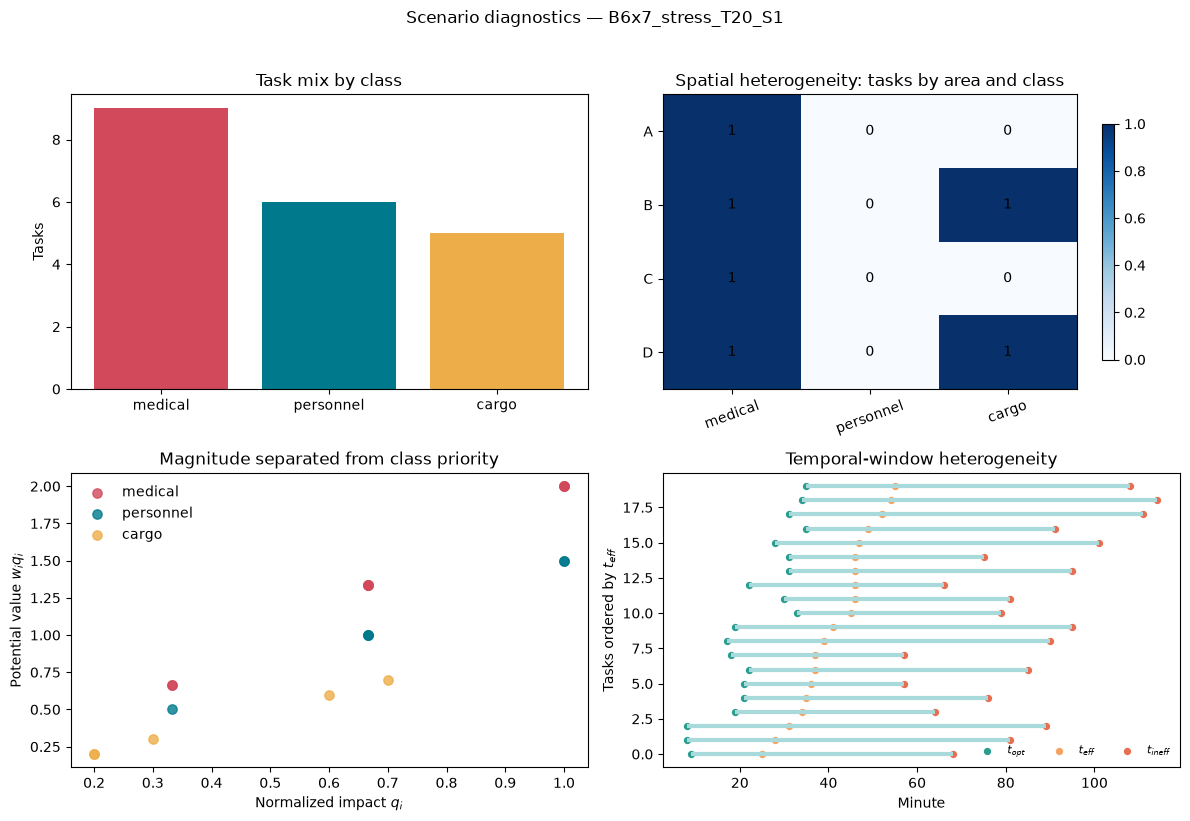

,Task ID,Area,Class,Visual Required,Raw Impact,Normalized Impact,Potential Value,t_opt,t_eff,t_ineff
0,1,E,medical,False,3.0,1.000000,2.000000,30.0,46.0,81.0
1,2,F,personnel,False,2.0,0.666667,1.000000,31.0,52.0,111.0
2,3,D,medical,False,2.0,0.666667,1.333333,35.0,55.0,108.0
3,4,C,medical,False,1.0,0.333333,0.666667,8.0,31.0,89.0
4,5,G,personnel,False,3.0,1.000000,1.500000,21.0,35.0,76.0
5,6,F,personnel,True,3.0,1.000000,1.500000,17.0,39.0,90.0
6,7,F,cargo,False,150.0,0.300000,0.300000,31.0,46.0,75.0
7,8,F,medical,False,2.0,0.666667,1.333333,35.0,49.0,91.0
8,9,F,medical,False,3.0,1.000000,2.000000,22.0,46.0,66.0
9,10,E,personnel,True,1.0,0.333333,0.500000,28.0,47.0,101.0


In [9]:
# ============================================================
# 12. DESCRIPTIVE DIAGNOSTICS BEFORE OPTIMIZATION
# ============================================================

def scenario_task_dataframe(scenario):
    rows = []
    for task_id, task in scenario["tasks"].items():
        rows.append({
            "Task ID": task_id,
            "Area": scenario["task_to_node"][task_id],
            "Class": task["priority_class"],
            "Visual Required": task["visual"],
            "Raw Impact": task["raw_impact"],
            "Normalized Impact": task["impact"],
            "Potential Value": task["potential_value"],
            "t_opt": task["t_opt"],
            "t_eff": task["t_eff"],
            "t_ineff": task["t_ineff"],
        })
    return pd.DataFrame(rows)


def plot_scenario_diagnostics(scenario, save=True):
    df = scenario_task_dataframe(scenario)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    class_counts = df["Class"].value_counts().reindex(TASK_CLASS_NAMES, fill_value=0)
    axes[0, 0].bar(class_counts.index, class_counts.values, color=["#D1495B", "#00798C", "#EDAe49"])
    axes[0, 0].set_title("Task mix by class")
    axes[0, 0].set_ylabel("Tasks")

    area_class = pd.crosstab(df["Area"], df["Class"]).reindex(
        index=["A", "B", "C", "D"], columns=TASK_CLASS_NAMES, fill_value=0
    )
    image = axes[0, 1].imshow(area_class.values, cmap="Blues", aspect="auto")
    axes[0, 1].set_xticks(range(len(area_class.columns)), area_class.columns, rotation=20)
    axes[0, 1].set_yticks(range(len(area_class.index)), area_class.index)
    axes[0, 1].set_title("Spatial heterogeneity: tasks by area and class")
    for i in range(area_class.shape[0]):
        for j in range(area_class.shape[1]):
            axes[0, 1].text(j, i, int(area_class.iloc[i, j]), ha="center", va="center")
    fig.colorbar(image, ax=axes[0, 1], shrink=0.8)

    for task_class, color in zip(TASK_CLASS_NAMES, ["#D1495B", "#00798C", "#EDAe49"]):
        subset = df[df["Class"] == task_class]
        axes[1, 0].scatter(
            subset["Normalized Impact"], subset["Potential Value"],
            label=task_class, color=color, alpha=0.8, s=45,
        )
    axes[1, 0].set_xlabel("Normalized impact $q_i$")
    axes[1, 0].set_ylabel("Potential value $w_i q_i$")
    axes[1, 0].set_title("Magnitude separated from class priority")
    axes[1, 0].legend(frameon=False)

    ordered = df.sort_values("t_eff").reset_index(drop=True)
    y = np.arange(len(ordered))
    axes[1, 1].hlines(y, ordered["t_opt"], ordered["t_ineff"], color="#A8DADC", lw=3)
    axes[1, 1].scatter(ordered["t_opt"], y, color="#2A9D8F", s=18, label="$t_{opt}$")
    axes[1, 1].scatter(ordered["t_eff"], y, color="#F4A261", s=18, label="$t_{eff}$")
    axes[1, 1].scatter(ordered["t_ineff"], y, color="#E76F51", s=18, label="$t_{ineff}$")
    axes[1, 1].set_xlabel("Minute")
    axes[1, 1].set_ylabel("Tasks ordered by $t_{eff}$")
    axes[1, 1].set_title("Temporal-window heterogeneity")
    axes[1, 1].legend(frameon=False, ncol=3, fontsize=8)

    fig.suptitle(f"Scenario diagnostics — {scenario['scenario_id']}", y=1.02)
    fig.tight_layout()
    if save:
        save_current_figure("A0_scenario_diagnostics.png")
    plt.show()
    return df


df_scenario_check = plot_scenario_diagnostics(scenario_check)
display(df_scenario_check.head(10))


## 13. Ejecución del Experimento B

La progresión experimental queda explícita:

1. micropruebas matemáticas e interpretación de (q_i);
2. diagnóstico de una instancia 6×7;
3. comparación de dos heurísticas constructivas;
4. perfil HiGHS bajo presupuesto computacional;
5. escalamiento sobre 20–60 tareas y 30 semillas en modo `paper`;
6. interpretación operacional mediante rutas, cronogramas, impacto por clase y eficiencia de vuelo;
7. trazabilidad por correlativo, `Run ID`, inicio, término, duración y *checkpoint* después de cada escenario.


In [ ]:
# ============================================================
# 14. RUN EXPERIMENT B WITH CORRELATIVE AND TIME TRACEABILITY
# ============================================================
expected_scenarios = (
    len(ACTIVE_TASK_COUNTS)
    * len(ACTIVE_SEEDS)
)

expected_methods_per_scenario = (
    len(GREEDY_RULES)
    + len(ACTIVE_HIGHS_BUDGETS)
)

expected_metric_rows = (
    expected_scenarios
    * expected_methods_per_scenario
)

if RUN_MODE == "paper":
    assert ACTIVE_TASK_COUNTS == [20, 30, 40, 50, 60]
    assert ACTIVE_SEEDS == list(range(1, 31))
    assert ACTIVE_HIGHS_BUDGETS == [1, 5, 15, 60, 600, 1800]
    assert set(GREEDY_RULES.values()) == {
        "Greedy-Benefit",
        "Greedy-Density-Operational",
    }
    assert HIGHS_METHOD == "HiGHS-1800s"
    assert expected_scenarios == 150
    assert expected_methods_per_scenario == 8
    assert expected_metric_rows == 1200

print("Pre-run configuration passed")
print("Expected scenarios:", expected_scenarios)
print("Expected methods per scenario:", expected_methods_per_scenario)
print("Expected metric rows:", expected_metric_rows)


experiment_started_at = datetime.now(EXECUTION_TIMEZONE)
experiment_start = time.perf_counter()

(
    df_metrics_scaling,
    df_logs_scaling,
    example_result,
    df_execution_trace,
) = run_experiment_suite(
    task_sizes=ACTIVE_TASK_COUNTS,
    seeds=ACTIVE_SEEDS,
    highs_budgets=ACTIVE_HIGHS_BUDGETS,
    verbose=False,
)

experiment_runtime = time.perf_counter() - experiment_start
experiment_finished_at = datetime.now(EXECUTION_TIMEZONE)

audit_experiment(
    df_metrics_scaling,
    df_logs_scaling,
    df_execution_trace,
    ACTIVE_TASK_COUNTS,
    ACTIVE_SEEDS,
    ACTIVE_HIGHS_BUDGETS,
)

metrics_path = OUTPUT_DIR / f"metrics_{RUN_PREFIX}_{TASK_GENERATOR_VERSION}.csv"
logs_path = OUTPUT_DIR / f"task_logs_{RUN_PREFIX}_{TASK_GENERATOR_VERSION}.csv"
trace_path = OUTPUT_DIR / f"execution_trace_{RUN_PREFIX}.csv"
experiment_summary_path = OUTPUT_DIR / f"experiment_summary_{RUN_PREFIX}.csv"

df_experiment_summary = pd.DataFrame([{
    "Execution ID": EXECUTION_ID,
    "Run Mode": RUN_MODE,
    "Started At": experiment_started_at.isoformat(timespec="seconds"),
    "Finished At": experiment_finished_at.isoformat(timespec="seconds"),
    "Elapsed sec": experiment_runtime,
    "Elapsed HH:MM:SS": format_elapsed(experiment_runtime),
    "Scenarios": len(df_execution_trace),
    "Task Counts": ",".join(str(value) for value in ACTIVE_TASK_COUNTS),
    "Seeds": ",".join(str(value) for value in ACTIVE_SEEDS),
    "HiGHS Budgets sec": ",".join(str(value) for value in ACTIVE_HIGHS_BUDGETS),
    "Status": "COMPLETED",
}])

df_metrics_scaling.to_csv(metrics_path, index=False)
df_logs_scaling.to_csv(logs_path, index=False)
df_execution_trace.to_csv(trace_path, index=False)
df_experiment_summary.to_csv(experiment_summary_path, index=False)

print(
    f"Experiment completed: {experiment_started_at:%Y-%m-%d %H:%M:%S %z} -> "
    f"{experiment_finished_at:%Y-%m-%d %H:%M:%S %z} | "
    f"elapsed={format_elapsed(experiment_runtime)}"
)
print("Saved:", metrics_path)
print("Saved:", logs_path)
print("Saved:", trace_path)
print("Saved:", experiment_summary_path)

display(df_experiment_summary)
display(df_execution_trace)
display(df_metrics_scaling)


Pre-run configuration passed
Expected scenarios: 1
Expected methods per scenario: 8
Expected metric rows: 8
[2026-08-25 15:51:31 -0400] EXPERIMENT START | id=20260825_155016-0400 | scenarios=1 | HiGHS budgets=[1, 5, 15, 60, 600, 1800] s
[2026-08-25 15:51:31 -0400] RUN 0001/0001 START | run_id=20260825_155016-0400-0001 | scenario=B6x7_stress_T50_S1 | tasks=50 | seed=1

Exact model structure
Scenario: B6x7_stress_T50_S1
Tasks: 50
Seed: 1
Variables: 747,224
States: 160,411
Constraints: 160,461
Reference structure successfully reproduced.


In [ ]:
# ============================================================
# 15. SUMMARY TABLES FOR ANALYSIS AND PAPER
# ============================================================

summary_source = df_metrics_scaling.copy()

summary_source["Has Incumbent"] = (
    summary_source["Has Incumbent"]
    .fillna(False)
    .astype(bool)
)

# Operationally available value:
# a run without incumbent contributes zero available value.
summary_source["Available Mission Value"] = (
    summary_source["Normalized Mission Value"]
    .fillna(0.0)
)

# Main comparison: two heuristics and HiGHS-1800s.
main_summary = (
    summary_source[
        summary_source["Method"].isin(METHOD_ORDER)
    ]
    .groupby(["Tasks", "Method"], observed=True)
    .agg(
        Runs=("Scenario", "size"),
        Incumbents=("Has Incumbent", "sum"),
        Mean_Conditional_Value=(
            "Normalized Mission Value", "mean"
        ),
        SD_Conditional_Value=(
            "Normalized Mission Value", "std"
        ),
        Mean_Available_Value=(
            "Available Mission Value", "mean"
        ),
        Mean_Completed_Tasks=(
            "Physical Completed Tasks", "mean"
        ),
        Mean_Response_Time=(
            "Average Response Time", "mean"
        ),
        Mean_End_to_End_sec=(
            "End-to-end sec", "mean"
        ),
    )
    .reset_index()
)

main_summary["Incumbent Rate"] = (
    main_summary["Incumbents"]
    / main_summary["Runs"]
)

# Complete HiGHS computational-budget profile.
anytime_source = summary_source[
    summary_source["Method"].str.startswith("HiGHS")
].copy()

anytime_source["Budget sec"] = (
    anytime_source["Method"]
    .str.extract(r"HiGHS-([0-9.]+)s")[0]
    .astype(float)
)

anytime_summary = (
    anytime_source
    .groupby(["Tasks", "Budget sec"], observed=True)
    .agg(
        Runs=("Scenario", "size"),
        Incumbents=("Has Incumbent", "sum"),
        Certified=("Optimal Certified", "sum"),
        Mean_Conditional_Value=(
            "Normalized Mission Value", "mean"
        ),
        SD_Conditional_Value=(
            "Normalized Mission Value", "std"
        ),
        Mean_Available_Value=(
            "Available Mission Value", "mean"
        ),
        Mean_MIP_Gap=("MIP Gap", "mean"),
        Mean_Solver_sec=("Solver Time sec", "mean"),
        Mean_End_to_End_sec=("End-to-end sec", "mean"),
    )
    .reset_index()
)

anytime_summary["Incumbent Rate"] = (
    anytime_summary["Incumbents"]
    / anytime_summary["Runs"]
)

anytime_summary["Certification Rate"] = (
    anytime_summary["Certified"]
    / anytime_summary["Runs"]
)

display(main_summary)
display(anytime_summary)

main_summary.to_csv(
    OUTPUT_DIR / f"paper_main_summary_{RUN_PREFIX}.csv",
    index=False,
)

anytime_summary.to_csv(
    OUTPUT_DIR / f"paper_anytime_summary_{RUN_PREFIX}.csv",
    index=False,
)

## 16. Figuras de calidad, impacto y escalamiento

Las figuras siguientes no son variaciones decorativas del mismo resultado. Cada una responde una pregunta distinta:

- ¿cuánto valor humanitario captura cada método?;
- ¿la mejora proviene de atender más tareas o de seleccionar tareas de mayor magnitud?;
- ¿qué clases reciben cobertura?;
- ¿qué valor adicional se obtiene al disponer de más tiempo de cómputo?;
- ¿cuánto cuesta esa mejora en vuelo y tiempo computacional?;
- ¿cómo crece la formulación y con qué frecuencia se certifica optimalidad?;


In [ ]:
# ============================================================
# 17. FIGURE A1 — QUALITY, IMPACT AND COMPLETED TASKS
# ============================================================

METHOD_COLORS = {
    "Greedy-Benefit": "#D55E00",
    "Greedy-Density-Operational": "#1C750B",
    HIGHS_METHOD: "#0072B2",
}

def plot_mission_value(df, save=True):
    plot_df = df[
        df["Method"].isin(METHOD_ORDER)
    ].copy()

    # If HiGHS does not find an incumbent, no operational plan
    # was available and its available mission value is zero.
    plot_df["Available Mission Value"] = (
        plot_df["Normalized Mission Value"]
        .fillna(0.0)
    )

    summary = (
        plot_df
        .groupby(
            ["Tasks", "Method"],
            observed=True,
        )["Available Mission Value"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    task_sizes = sorted(
        plot_df["Tasks"].unique()
    )

    fig, ax = plt.subplots(
        figsize=(9.0, 5.2)
    )

    for method in METHOD_ORDER:
        group = (
            summary[
                summary["Method"] == method
            ]
            .set_index("Tasks")
            .reindex(task_sizes)
        )

        mean_values = group["mean"].to_numpy()

        std_values = (
            group["std"]
            .fillna(0.0)
            .to_numpy()
        )

        color = METHOD_COLORS[method]
        label = METHOD_LABELS[method]

        # Mean mission value.
        ax.plot(
            task_sizes,
            mean_values,
            marker="o",
            markersize=5.5,
            linewidth=2.2,
            color=color,
            label=label,
        )

        # ±1 standard deviation.
        ax.fill_between(
            task_sizes,
            np.maximum(
                0.0,
                mean_values - std_values,
            ),
            np.minimum(
                1.0,
                mean_values + std_values,
            ),
            color=color,
            alpha=0.15,
            linewidth=0,
        )

    ax.set_xticks(task_sizes)

    ax.set_xlabel(
        "Number of tasks"
    )

    ax.set_ylabel(
        "Mean normalized accumulated benefit"
    )

    ax.set_ylim(0.0, 1.0)

    ax.grid(
        True,
        axis="both",
        linestyle="--",
        linewidth=0.6,
        alpha=0.65,
    )

    ax.legend(
        loc="best",
        frameon=False,
    )

    # Black frame consistent with the previous notebook.
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    fig.tight_layout()

    if save:
        save_current_figure(
            "A1_mission_value.pdf",
            dpi=2000,
        )

    plt.show()

    return summary


a1_summary = plot_mission_value(
    df_metrics_scaling
)

In [ ]:
def plot_computational_time(df, save=True):
    summary = (
        df.groupby(["Tasks", "Method"], observed=True)[
            "End-to-end sec"
        ]
        .mean()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    for method in METHOD_ORDER:
        subset = (
            summary[summary["Method"] == method]
            .sort_values("Tasks")
        )

        if subset.empty:
            continue

        ax.plot(
            subset["Tasks"],
            subset["End-to-end sec"],
            marker="o",
            markersize=5,
            linewidth=2,
            color=METHOD_COLORS[method],
            label=METHOD_LABELS[method],
        )

    ax.set_xlabel("Number of tasks")
    ax.set_ylabel("End-to-end time (s)")
    ax.set_yscale("log")
    ax.set_xticks(sorted(df["Tasks"].unique()))
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)

    fig.tight_layout()

    if save:
        save_current_figure("A2_computational_time_three_methods.pdf")

    plt.show()


plot_computational_time(df_metrics_scaling)

In [ ]:
# ============================================================
# 19. FIGURE A3 — HIGHS COMPUTATIONAL-BUDGET SENSITIVITY
# ============================================================

def plot_highs_budget_profile(df, save=True):

    # --------------------------------------------------------
    # 1. Prepare HiGHS results
    # --------------------------------------------------------

    exact = df[
        df["Method"].str.startswith(
            "HiGHS",
            na=False,
        )
    ].copy()

    exact["Budget sec"] = (
        exact["Method"]
        .str.extract(
            r"HiGHS-([0-9.]+)s",
            expand=False,
        )
        .astype(float)
    )

    # No incumbent means that no operational plan was available.
    exact["Available Mission Value"] = (
        exact["Normalized Mission Value"]
        .fillna(0.0)
        .astype(float)
    )

    # A reported incumbent can be an empty plan.
    # Operational availability therefore requires positive value.
    exact["Has Positive Plan"] = (
        exact["Available Mission Value"] > 0.0
    )

    exact["Optimal Certified"] = (
        exact["Optimal Certified"]
        .fillna(False)
        .astype(bool)
    )

    budgets = sorted(
        exact["Budget sec"].unique()
    )

    task_counts = sorted(
        exact["Tasks"].unique()
    )

    benchmark_budget = max(budgets)

    # --------------------------------------------------------
    # 2. Certified benchmark for each individual instance
    # --------------------------------------------------------

    benchmark = (
        exact[
            exact["Budget sec"] == benchmark_budget
        ][
            [
                "Scenario",
                "Tasks",
                "Available Mission Value",
                "Optimal Certified",
            ]
        ]
        .rename(
            columns={
                "Available Mission Value":
                    "Benchmark Mission Value",
                "Optimal Certified":
                    "Benchmark Certified",
            }
        )
    )

    # The term "optimal" is valid only if every 600-s result
    # was mathematically certified.
    benchmark_certification_rate = (
        benchmark["Benchmark Certified"].mean()
    )

    print(
        f"{benchmark_budget:g}-s benchmark certification rate: "
        f"{benchmark_certification_rate:.1%}"
    )

    if (
        benchmark["Benchmark Mission Value"] <= 0.0
    ).any():
        raise RuntimeError(
            "Every benchmark mission value must be positive."
        )

    exact = exact.merge(
        benchmark[
            [
                "Scenario",
                "Tasks",
                "Benchmark Mission Value",
            ]
        ],
        on=["Scenario", "Tasks"],
        how="left",
        validate="many_to_one",
    )

    # Paired recovery:
    # each time-limited result is compared with the certified
    # optimum of exactly the same instance.
    exact["Recovered Benchmark Value"] = (
        exact["Available Mission Value"]
        / exact["Benchmark Mission Value"]
    )

    if (
        exact["Recovered Benchmark Value"]
        > 1.0 + 1e-6
    ).any():
        raise RuntimeError(
            "A time-limited result exceeds its certified "
            "benchmark beyond numerical tolerance."
        )

    exact["Recovered Benchmark Value"] = (
        exact["Recovered Benchmark Value"]
        .clip(0.0, 1.0)
    )

    # --------------------------------------------------------
    # 3. Aggregate the 30 seeds
    # --------------------------------------------------------

    summary = (
        exact
        .groupby(
            ["Tasks", "Budget sec"],
            observed=True,
        )
        .agg(
            Runs=(
                "Scenario",
                "nunique",
            ),
            Mean_Benchmark_Recovery=(
                "Recovered Benchmark Value",
                "mean",
            ),
            Positive_Plans=(
                "Has Positive Plan",
                "sum",
            ),
            Positive_Plan_Rate=(
                "Has Positive Plan",
                "mean",
            ),
            Certified=(
                "Optimal Certified",
                "sum",
            ),
            Certification_Rate=(
                "Optimal Certified",
                "mean",
            ),
        )
        .reset_index()
        .sort_values(
            ["Tasks", "Budget sec"]
        )
    )

    certification_matrix = (
        summary
        .pivot(
            index="Tasks",
            columns="Budget sec",
            values="Certification_Rate",
        )
        .reindex(
            index=task_counts,
            columns=budgets,
        )
    )

    # --------------------------------------------------------
    # 4. Two-panel figure
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10.8, 4.6),
        constrained_layout=True,
        gridspec_kw={
            "width_ratios": [1.35, 1.0]
        },
    )

    task_colors = {
        20: "#0072B2",  # blue
        30: "#E69F00",  # amber
        40: "#009E73",  # green
        50: "#D55E00",  # vermilion
        60: "#6A3D9A",  # purple
    }

    # --------------------------------------------------------
    # Panel (a): recovered certified optimum
    # --------------------------------------------------------

    for n_tasks in task_counts:

        subset = (
            summary[
                summary["Tasks"] == n_tasks
            ]
            .set_index("Budget sec")
            .reindex(budgets)
        )

        axes[0].plot(
            budgets,
            100.0
            * subset["Mean_Benchmark_Recovery"],
            marker="o",
            markersize=5,
            linewidth=2.0,
            color=task_colors[n_tasks],
            label=f"{int(n_tasks)}",
        )

    axes[0].axhline(
        100.0,
        color="0.45",
        linestyle="--",
        linewidth=1.0,
        zorder=0,
    )

    axes[0].set_xscale("log")

    axes[0].set_xticks(
        budgets,
        [
            f"{budget:g}"
            for budget in budgets
        ],
    )

    axes[0].set_ylim(
        0.0,
        105.0,
    )

    axes[0].set_yticks(
        np.arange(
            0.0,
            101.0,
            20.0,
        )
    )

    axes[0].set_xlabel(
        "HiGHS time limit (s)"
    )

    axes[0].set_ylabel(
        "Optimal Mission Value (%)"
    )

    axes[0].set_title(
        "Mission value achieved"
    )

    axes[0].grid(
        axis="y",
        linestyle="--",
        linewidth=0.6,
        alpha=0.55,
    )

    axes[0].legend(
        title="Tasks",
        loc="lower right",
        frameon=False,
    )

    # --------------------------------------------------------
    # Heatmap helper
    # --------------------------------------------------------

    def draw_rate_heatmap(
        axis,
        matrix,
        title,
    ):

        image = axis.imshow(
            matrix.to_numpy(
                dtype=float
            ),
            vmin=0.0,
            vmax=1.0,
            cmap="Blues",
            aspect="auto",
        )

        axis.set_xticks(
            np.arange(
                len(budgets)
            ),
            [
                f"{budget:g}"
                for budget in budgets
            ],
        )

        axis.set_yticks(
            np.arange(
                len(task_counts)
            ),
            [
                f"{int(n_tasks)}"
                for n_tasks in task_counts
            ],
        )

        axis.set_xlabel(
            "HiGHS time limit (s)"
        )

        axis.set_title(title)

        # White cell borders.
        axis.set_xticks(
            np.arange(
                -0.5,
                len(budgets),
                1.0,
            ),
            minor=True,
        )

        axis.set_yticks(
            np.arange(
                -0.5,
                len(task_counts),
                1.0,
            ),
            minor=True,
        )

        axis.grid(
            which="minor",
            color="white",
            linewidth=0.8,
        )

        axis.tick_params(
            which="minor",
            bottom=False,
            left=False,
        )

        # Percentage annotations.
        for row in range(
            matrix.shape[0]
        ):
            for column in range(
                matrix.shape[1]
            ):
                value = matrix.iloc[
                    row,
                    column,
                ]

                if np.isfinite(value):
                    axis.text(
                        column,
                        row,
                        f"{100.0 * value:.0f}%",
                        ha="center",
                        va="center",
                        color=(
                            "white"
                            if value >= 0.55
                            else "black"
                        ),
                        fontsize=8.5,
                    )

        return image

    # --------------------------------------------------------
    # Panel (b): certified optimality
    # --------------------------------------------------------

    draw_rate_heatmap(
        axes[1],
        certification_matrix,
        "Optimality certification",
    )

    axes[1].set_ylabel(
        "Number of tasks"
    )

    # --------------------------------------------------------
    # Panel labels
    # --------------------------------------------------------

    for panel_label, axis in zip(
        ["(a)", "(b)"],
        axes,
    ):
        axis.text(
            -0.13,
            1.04,
            panel_label,
            transform=axis.transAxes,
            ha="left",
            va="bottom",
            fontweight="bold",
            fontsize=10,
            clip_on=False,
    )

    # --------------------------------------------------------
    # Save and show
    # --------------------------------------------------------

    if save:
        save_current_figure(
            "A3_highs_budget_profile.pdf",
            dpi=2000,
        )

    plt.show()

    return summary


a3_summary = plot_highs_budget_profile(
    df_metrics_scaling
)

In [ ]:
# ============================================================
# 20. FIGURE A4 — OPERATIONAL AND COMPUTATIONAL TRADE-OFFS
# ============================================================

def plot_tradeoffs(df, save=True):
    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))
    for method in METHOD_ORDER:
        subset = df[df["Method"] == method]
        if subset.empty:
            continue
        axes[0].scatter(
            subset["Total Flight Time"], subset["Normalized Mission Value"],
            label=method, alpha=0.7, s=35, color=METHOD_COLORS.get(method),
        )
        summary = subset.groupby("Tasks")["Runtime sec"].mean().reset_index()
        axes[1].plot(
            summary["Tasks"], summary["Runtime sec"], marker="o",
            label=method, color=METHOD_COLORS.get(method),
        )
        efficiency = subset.groupby("Tasks")["Value per Flight Minute"].mean().reset_index()
        axes[2].plot(
            efficiency["Tasks"], efficiency["Value per Flight Minute"], marker="o",
            label=method, color=METHOD_COLORS.get(method),
        )
    axes[0].set_xlabel("Total flight time (min)")
    axes[0].set_ylabel("Normalized mission value")
    axes[0].set_title("Primal value versus flight effort")
    axes[1].set_xlabel("Number of tasks")
    axes[1].set_ylabel("Method runtime (s, log scale)")
    axes[1].set_yscale("log")
    axes[1].set_title("Computational cost")
    axes[2].set_xlabel("Number of tasks")
    axes[2].set_ylabel("Mission value / flight minute")
    axes[2].set_title("Operational efficiency")
    for ax in axes:
        ax.grid(alpha=0.25)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=min(4, len(labels)), frameon=False)
    fig.suptitle("Operational and computational trade-offs", y=1.08)
    fig.tight_layout()
    if save:
        save_current_figure("A4_tradeoffs.pdf")
    plt.show()


plot_tradeoffs(df_metrics_scaling)


In [ ]:
# ============================================================
# 21. FIGURE A5 — MILP GROWTH AND DENSITY ADVANTAGE
# ============================================================

def plot_model_growth_and_paired_advantage(df, save=True):
    exact = df[df["Method"].str.startswith("HiGHS")].copy()
    growth = (
        exact.groupby(["Scenario", "Tasks"], observed=True)
        .agg(Variables=("Variables", "first"), Constraints=("Constraints", "first"), Nonzeros=("Nonzeros", "first"))
        .reset_index()
        .groupby("Tasks")[["Variables", "Constraints", "Nonzeros"]]
        .mean().reset_index()
    )

    pivot = df.pivot(index=["Scenario", "Tasks"], columns="Method", values="Normalized Mission Value")
    differences = []
    comparisons = [
        (
            "Greedy-Density-Operational",
            "Greedy-Benefit",
            "Density-operational − Benefit",
        ),
    ]
    best_highs = f"HiGHS-{max(ACTIVE_HIGHS_BUDGETS):g}s"
    comparisons.append((best_highs, "Greedy-Density-Operational", f"{best_highs} − Density-operational"))
    for left, right, label in comparisons:
        if left in pivot.columns and right in pivot.columns:
            values = (pivot[left] - pivot[right]).dropna()
            for (scenario, tasks), value in values.items():
                differences.append({"Scenario": scenario, "Tasks": tasks, "Comparison": label, "Difference": value})
    diff_df = pd.DataFrame(differences)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    axes[0].plot(growth["Tasks"], growth["Variables"], marker="o", label="Variables")
    axes[0].plot(growth["Tasks"], growth["Constraints"], marker="s", label="Constraints")
    axes[0].plot(growth["Tasks"], growth["Nonzeros"], marker="^", label="Nonzeros")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Number of tasks")
    axes[0].set_ylabel("Mean count (log scale)")
    axes[0].set_title("State–arc MILP growth")
    axes[0].legend(frameon=False)
    axes[0].grid(alpha=0.25)

    if not diff_df.empty:
        labels = list(diff_df["Comparison"].unique())
        data = [diff_df[diff_df["Comparison"] == label]["Difference"] for label in labels]
        axes[1].boxplot(data, tick_labels=labels, showmeans=True)
        axes[1].axhline(0, color="black", lw=1)
        axes[1].tick_params(axis="x", rotation=18)
    axes[1].set_ylabel("Paired mission-value difference")
    axes[1].set_title("Does each methodological addition help?")
    axes[1].grid(axis="y", alpha=0.25)
    fig.tight_layout()
    if save:
        save_current_figure("A5_model_growth_paired_advantage.png")
    plt.show()
    return diff_df


df_paired_advantage = plot_model_growth_and_paired_advantage(df_metrics_scaling)
display(df_paired_advantage.groupby("Comparison")["Difference"].agg(["mean", "std", "min", "max", "count"]) if not df_paired_advantage.empty else df_paired_advantage)


## 22. Interpretabilidad operacional de una instancia

Los promedios no permiten verificar si una política genera secuencias razonables. Por eso se incluyen:

- mapa de rutas por helicóptero y método;
- cronograma tipo Gantt;
- curvas acumuladas de valor capturado;
- marcas de retorno y recuperación.

Estas figuras se construyen con la primera instancia ejecutada y no intervienen en la optimización.


In [ ]:
# ============================================================
# 23. FIGURE A6 — ROUTE MAPS
# ============================================================

HELO_COLORS = {
    1: "#1D3557",
    2: "#E63946",
    3: "#2A9D8F",
    4: "#F4A261",
    5: "#6A3D9A",
    6: "#8C564B",
}


def plot_route_maps(result, save=True):
    scenario = result["scenario"]
    methods = METHOD_ORDER
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    flat_axes = axes.ravel()
    for ax, method in zip(flat_axes, methods):
        df = result["method_logs"].get(method, pd.DataFrame())
        task_labels = defaultdict(list)
        for node, (x, y) in scenario["nodes"].items():
            marker = "*" if node == "Base" else "o"
            size = 190 if node == "Base" else 95
            ax.scatter(x, y, marker=marker, s=size, color="black" if node == "Base" else "white", edgecolor="black", zorder=4)
            ax.text(x + 0.8, y + 0.6, node, fontsize=9)
        if df is not None and not df.empty:
            for helo_id, helo_df in df.groupby("Helo ID"):
                helo_df = helo_df.sort_values("Completion Time")
                for _, row in helo_df.iterrows():
                    x0, y0 = scenario["nodes"][row["Start Node"]]
                    x1, y1 = scenario["nodes"][row["Node"]]
                    ax.annotate(
                        "", xy=(x1, y1), xytext=(x0, y0),
                        arrowprops=dict(arrowstyle="->", color=HELO_COLORS[int(helo_id)], lw=1.6, alpha=0.8),
                    )
                    if row["Status"] == "Task Executed":
                        task_labels[(int(helo_id), row["Node"])].append(int(row["Task ID"]))
        label_offsets = {
            1: (-2.6, -1.8),
            2: (0.5, -1.8),
            3: (-2.6, 1.0),
            4: (0.5, 1.0),
            5: (-2.6, 2.8),
            6: (0.5, 2.8),
        }
        for (helo_id, node), task_ids in task_labels.items():
            x, y = scenario["nodes"][node]
            dx, dy = label_offsets[helo_id]
            sequence = ",".join(str(task_id) for task_id in task_ids)
            ax.text(
                x + dx, y + dy, f"H{helo_id}: {sequence}",
                fontsize=6.5, color=HELO_COLORS[helo_id],
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.65, pad=0.5),
                zorder=5,
            )
        ax.set_title(method)
        ax.set_xlabel("Cartesian x")
        ax.set_ylabel("Cartesian y")
        ax.grid(alpha=0.2)
        ax.set_aspect("equal", adjustable="box")
        x_values = [
            coordinates[0]
            for coordinates
            in scenario["nodes"].values()
        ]

        y_values = [
            coordinates[1]
            for coordinates
            in scenario["nodes"].values()
        ]

        ax.set_xlim(
            min(x_values) - 5,
            max(x_values) + 5,
        )

        ax.set_ylim(
            min(y_values) - 5,
            max(y_values) + 5,
        )
    for ax in flat_axes[len(methods):]:
        ax.set_visible(False)
    fig.suptitle(f"Route interpretation — {scenario['scenario_id']}", y=0.99)
    fig.tight_layout()
    if save:
        save_current_figure("A6_route_maps.png")
    plt.show()


plot_route_maps(example_result)


In [ ]:
# ============================================================
# 24. FIGURE A7 — GANTT AND CUMULATIVE VALUE
# ============================================================

def plot_gantt_and_value(result, save=True):
    methods = METHOD_ORDER
    fig, axes = plt.subplots(len(methods), 2, figsize=(14, 3.2 * len(methods)))
    for row_index, method in enumerate(methods):
        df = result["method_logs"].get(method, pd.DataFrame())
        gantt_ax, value_ax = axes[row_index]
        if df is None or df.empty:
            gantt_ax.text(0.5, 0.5, "No incumbent", transform=gantt_ax.transAxes, ha="center")
            value_ax.text(0.5, 0.5, "No incumbent", transform=value_ax.transAxes, ha="center")
            continue

        for _, event in df.sort_values("Start Time").iterrows():
            helo = int(event["Helo ID"])
            duration = event["Completion Time"] - event["Start Time"]
            color = HELO_COLORS[helo] if event["Status"] == "Task Executed" else "#BDBDBD"
            gantt_ax.barh(helo, duration, left=event["Start Time"], height=0.55, color=color, alpha=0.85)
            label = f"T{int(event['Task ID'])}" if event["Status"] == "Task Executed" else "R"
            gantt_ax.text(event["Start Time"] + duration / 2, helo, label, ha="center", va="center", fontsize=7)

        task_df = df[df["Status"] == "Task Executed"].sort_values("Completion Time").copy()
        task_df["Cumulative Value"] = task_df["Benefit"].cumsum()
        value_ax.step(task_df["Completion Time"], task_df["Cumulative Value"], where="post", color="#264653", lw=2)
        value_ax.scatter(task_df["Completion Time"], task_df["Cumulative Value"], color="#264653", s=18)

        helo_ids = sorted(
            helo_to_int(h)
            for h in result["scenario"]["helicopters"]
        )

        gantt_ax.set_yticks(
            helo_ids,
            [f"H{h}" for h in helo_ids],
        )
        gantt_ax.set_ylabel(method)
        gantt_ax.set_xlabel("Minute")
        gantt_ax.grid(axis="x", alpha=0.2)
        value_ax.set_xlabel("Completion minute")
        value_ax.set_ylabel("Cumulative mission value")
        value_ax.set_ylim(bottom=0)
        value_ax.grid(alpha=0.2)
    axes[0, 0].set_title("Mission timeline (R = return/recovery)")
    axes[0, 1].set_title("When is humanitarian value captured?")
    fig.tight_layout()
    if save:
        save_current_figure("A7_gantt_cumulative_value.png")
    plt.show()


plot_gantt_and_value(example_result)


In [ ]:
# ============================================================
# A8 — COMBINED COMPUTATIONAL FIGURE
# (a) Exact computational effort
# (b) Feasible state-transition arcs versus runtime
# ============================================================

from matplotlib.lines import Line2D

SOLVER_TIME_LIMIT = HIGHS_BENCHMARK_BUDGET  # 1800 s

# Un registro Exact principal por escenario.
exact = df_metrics_scaling[
    df_metrics_scaling["Method"] == HIGHS_METHOD
].copy()

runtime_column = "Solver Time sec"

exact_plot = exact.dropna(
    subset=[
        "Tasks",
        "Variables",
        runtime_column,
    ]
).copy()

if exact_plot.empty:
    raise RuntimeError(
        f"No records available for {HIGHS_METHOD}."
    )

task_sizes = sorted(
    exact_plot["Tasks"].unique()
)

task_min = min(task_sizes)
task_max = max(task_sizes)

normalization = plt.Normalize(
    task_min,
    task_max,
)

cmap = plt.get_cmap("viridis")
rng = np.random.default_rng(7)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.8),
    constrained_layout=True,
)

ax_effort = axes[0]
ax_structure = axes[1]

for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

# ------------------------------------------------------------
# Panel (a): Exact computational effort
# ------------------------------------------------------------

for certified_status, marker, label in [
    (True, "o", "Certified optimum"),
    (False, "X", "Non-certified run"),
]:
    subset = exact_plot[
        exact_plot["Optimal Certified"].fillna(False)
        == certified_status
    ].copy()

    jitter = rng.uniform(
        -0.75,
        0.75,
        size=len(subset),
    )

    ax_effort.scatter(
        subset["Tasks"] + jitter,
        subset[runtime_column],
        c=subset["Tasks"],
        cmap=cmap,
        norm=normalization,
        marker=marker,
        s=45 if certified_status else 65,
        alpha=0.75,
        edgecolor="black",
        linewidth=0.4,
        label=label,
        zorder=3,
    )

runtime_summary = (
    exact_plot
    .groupby("Tasks")[runtime_column]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
    )
    .reindex(task_sizes)
)

ax_effort.plot(
    task_sizes,
    runtime_summary["median"],
    color="black",
    marker="D",
    markersize=5,
    linewidth=1.6,
    label="Median",
    zorder=4,
)

ax_effort.fill_between(
    task_sizes,
    runtime_summary["q25"],
    runtime_summary["q75"],
    color="black",
    alpha=0.10,
    label="Interquartile range",
)

ax_effort.axhline(
    SOLVER_TIME_LIMIT,
    color="#CC3311",
    linestyle="--",
    linewidth=1.5,
    label=f"t-limit: {SOLVER_TIME_LIMIT:,} s",
)

ax_effort.set_yscale("log")
ax_effort.set_xlabel("Number of tasks")
ax_effort.set_ylabel("Exact runtime (s, log scale)")
ax_effort.set_title("(a) Exact computational effort")
ax_effort.set_xticks(task_sizes)
ax_effort.grid(
    True,
    which="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.7,
)
ax_effort.legend(
    frameon=True,
    fontsize=8,
    loc="lower right",
)

# ------------------------------------------------------------
# Panel (b): feasible arcs versus runtime
# ------------------------------------------------------------

for certified_status, marker, label in [
    (True, "o", "Certified optimum"),
    (False, "X", "Non-certified run"),
]:
    subset = exact_plot[
        exact_plot["Optimal Certified"].fillna(False)
        == certified_status
    ]

    ax_structure.scatter(
        subset["Variables"],
        subset[runtime_column],
        c=subset["Tasks"],
        cmap=cmap,
        norm=normalization,
        marker=marker,
        s=50 if certified_status else 70,
        alpha=0.78,
        edgecolor="black",
        linewidth=0.4,
        label=label,
        zorder=3,
    )

ax_structure.axhline(
    SOLVER_TIME_LIMIT,
    color="#CC3311",
    linestyle="--",
    linewidth=1.5,
    label=f"t-limit: {SOLVER_TIME_LIMIT:,} s",
)

ax_structure.set_xscale("log")
ax_structure.set_yscale("log")

ax_structure.set_xlabel(
    "Feasible state-transition arcs\n"
    "(binary decision variables)"
)
ax_structure.set_title(
    "(b) State–arc network size and runtime"
)

ax_structure.grid(
    True,
    which="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.7,
)

ax_structure.legend(
    frameon=True,
    fontsize=8,
    loc="lower right",
)

# Barra de color común.
color_mapper = plt.cm.ScalarMappable(
    norm=normalization,
    cmap=cmap,
)
color_mapper.set_array([])

colorbar = fig.colorbar(
    color_mapper,
    ax=axes,
    fraction=0.025,
    pad=0.025,
)
colorbar.set_label("Number of tasks")

save_current_figure(
    "A8_exact_computational_effort_and_state_arc_size.pdf",
    dpi=2000,
)

plt.show()